# Explainable Deep Learning for Chest CT Lung Cancer Classification

**Independent Kaggle implementation — secondary data only**

This notebook implements the research plan as a reproducible pipeline:
**dataset audit → EDA → leakage control → preprocessing → Custom CNN → EfficientNetB0 → DenseNet121 → validation macro-F1 model selection → one-time held-out test evaluation → Grad-CAM → error analysis → Flask deployment bundle**.

### Target classes
- Normal
- Adenocarcinoma
- Large-cell carcinoma
- Squamous-cell carcinoma

### Dataset and licence
- **Chest CT-Scan Images** by Mohamed Hany: https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images
- **Open Data Commons Open Database License (ODbL) v1.0**: https://opendatacommons.org/licenses/odbl/1-0/

### Ethics position
Only existing secondary JPG/PNG images are used. No participants are recruited, no new scans or clinical records are collected, and no attempt is made to identify patients, clinicians, hospitals or organisations.

> **Academic prototype only.** Outputs are not clinical diagnoses, medical-device outputs or treatment recommendations.

## Methodological safeguards

This implementation is intentionally different from the reference code and is designed around the submitted research plan:

1. The `train`, `valid` and `test` folders are never swapped.
2. Actual image counts are measured directly from disk.
3. Corrupt files, exact duplicates and cross-split perceptual near-duplicates are audited.
4. Exact duplicate leakage can be removed deterministically before modelling.
5. Only training images are augmented; no vertical flips are used.
6. All candidates are selected using **validation macro-F1**, not training accuracy.
7. The held-out **test set is evaluated only after the final model has been chosen**.
8. Final reporting includes balanced accuracy, sensitivity, specificity, macro/weighted F1, ROC-AUC, confusion matrices, confidence/error analysis and Grad-CAM.
9. The selected model is exported with a local Flask application.

In [11]:
# 1. Imports, reproducibility and configuration
import os, gc, json, math, time, hashlib, shutil, random, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

ImageFile.LOAD_TRUNCATED_IMAGES = True
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
FAST_DEV_RUN = False
STRICT_LEAKAGE_CONTROL = True
NEAR_DUPLICATE_HAMMING_THRESHOLD = 5
CUSTOM_EPOCHS = 28 if not FAST_DEV_RUN else 2
HEAD_EPOCHS = 14 if not FAST_DEV_RUN else 2
FINETUNE_EPOCHS = 12 if not FAST_DEV_RUN else 1
FINE_TUNE_LAYERS = 35

CLASS_NAMES = ['normal','adenocarcinoma','large_cell_carcinoma','squamous_cell_carcinoma']
CLASS_TO_INDEX = {name:i for i,name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

PROJECT_DIR = Path('/kaggle/working/chest_ct_explainable_project')
MODEL_DIR = PROJECT_DIR/'models'
FIGURE_DIR = PROJECT_DIR/'figures'
REPORT_DIR = PROJECT_DIR/'reports'
FLASK_DIR = PROJECT_DIR/'flask_app'
for d in [PROJECT_DIR, MODEL_DIR, FIGURE_DIR, REPORT_DIR, FLASK_DIR]: d.mkdir(parents=True, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); keras.utils.set_random_seed(SEED)
try: tf.config.experimental.enable_op_determinism()
except Exception: pass

print({'python':platform.python_version(),'tensorflow':tf.__version__,
       'gpu_available':bool(tf.config.list_physical_devices('GPU')),
       'seed':SEED,'image_size':IMG_SIZE,'batch_size':BATCH_SIZE})

{'python': '3.12.13', 'tensorflow': '2.20.0', 'gpu_available': True, 'seed': 42, 'image_size': (224, 224), 'batch_size': 32}


In [12]:
# 2. Consistent dissertation visual style
PALETTE = {'navy':'#17324D','blue':'#2F80ED','teal':'#16A085','green':'#27AE60',
           'orange':'#F2994A','red':'#EB5757','purple':'#8E5AD7','grey':'#7F8C8D'}
plt.rcParams.update({'figure.figsize':(10,6),'figure.dpi':120,'axes.titlesize':16,
                     'axes.titleweight':'bold','axes.labelsize':11,'axes.grid':True,
                     'grid.alpha':0.18,'axes.spines.top':False,'axes.spines.right':False,'font.size':10})
def save_figure(name):
    path = FIGURE_DIR/f'{name}.png'
    plt.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    print('Saved:', path)

## 1. Discover the attached Kaggle dataset
The normal Kaggle location is `/kaggle/input/chest-ctscan-images/Data`. A guarded fallback search is included so the notebook remains reusable if Kaggle changes the mount path.

In [13]:
# 3. Robust dataset discovery and canonical labels
def canonical_class(folder_name):
    text = folder_name.lower().replace('-',' ').replace('_',' ').replace('.',' ')
    if 'normal' in text: return 'normal'
    if 'adenocarcinoma' in text or 'adeno' in text: return 'adenocarcinoma'
    if 'large' in text and 'carcinoma' in text: return 'large_cell_carcinoma'
    if 'squamous' in text and 'carcinoma' in text: return 'squamous_cell_carcinoma'
    return None

def root_looks_valid(root):
    root = Path(root)
    if not root.exists() or not all((root/s).exists() for s in ['train','valid','test']): return False
    recognised=set()
    for split in ['train','valid','test']:
        for child in (root/split).iterdir():
            if child.is_dir() and canonical_class(child.name): recognised.add(canonical_class(child.name))
    return set(CLASS_NAMES).issubset(recognised)

candidates=[Path('/kaggle/input/chest-ctscan-images/Data'),Path('/kaggle/input/chest-ctscan-images/data')]
DATA_ROOT=next((p for p in candidates if root_looks_valid(p)),None)
if DATA_ROOT is None:
    for p in Path('/kaggle/input').rglob('train'):
        if root_looks_valid(p.parent): DATA_ROOT=p.parent; break
if DATA_ROOT is None:
    raise FileNotFoundError("Attach Kaggle dataset 'mohamedhanyyy/chest-ctscan-images' and rerun.")
print('Dataset root:', DATA_ROOT)

Dataset root: /kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data


In [14]:
# 4. Build a transparent master manifest
IMAGE_EXTENSIONS={'.jpg','.jpeg','.png','.bmp'}
rows=[]
for split in ['train','valid','test']:
    for class_dir in sorted([p for p in (DATA_ROOT/split).iterdir() if p.is_dir()]):
        label=canonical_class(class_dir.name)
        if not label: continue
        for p in sorted(class_dir.rglob('*')):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append({'path':str(p),'filename':p.name,'source_folder':class_dir.name,
                             'split':split,'label':label,'label_idx':CLASS_TO_INDEX[label],
                             'extension':p.suffix.lower()})
manifest=pd.DataFrame(rows)
if manifest.empty: raise RuntimeError('No CT images found.')
manifest.to_csv(REPORT_DIR/'dataset_manifest_raw.csv',index=False)
print('Total images:',len(manifest))
display(manifest.groupby(['split','label']).size().rename('images').reset_index())

Total images: 1000


,split,label,images
0,test,adenocarcinoma,120
1,test,large_cell_carcinoma,51
2,test,normal,54
3,test,squamous_cell_carcinoma,90
4,train,adenocarcinoma,195
5,train,large_cell_carcinoma,115
6,train,normal,148
7,train,squamous_cell_carcinoma,155
8,valid,adenocarcinoma,23
9,valid,large_cell_carcinoma,21


## 2. Data-quality audit and EDA
The next stage records image dimensions, aspect ratio, file size, intensity statistics, corruption status, SHA-256 and perceptual dHash. These outputs provide evidence for the dissertation's data-quality section.

In [15]:
# 5. Image-level audit, exact hash and perceptual hash
def sha256_file(path, chunk=1024*1024):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        while True:
            b=f.read(chunk)
            if not b: break
            h.update(b)
    return h.hexdigest()

def dhash_image(path, hash_size=8):
    with Image.open(path) as im:
        g=im.convert('L').resize((hash_size+1,hash_size),Image.Resampling.LANCZOS)
        a=np.asarray(g,dtype=np.int16)
    diff=a[:,1:]>a[:,:-1]
    value=0
    for bit in diff.flatten(): value=(value<<1)|int(bit)
    return value

def inspect_image(path):
    try:
        with Image.open(path) as im: im.verify()
        with Image.open(path) as im:
            rgb=im.convert('RGB'); w,h=rgb.size
            preview=np.asarray(rgb.resize((64,64)),dtype=np.float32)
        return {'corrupt':False,'width':w,'height':h,'aspect_ratio':w/h if h else np.nan,
                'file_kb':os.path.getsize(path)/1024,'mean_intensity':float(preview.mean()),
                'std_intensity':float(preview.std()),'sha256':sha256_file(path),'dhash_int':dhash_image(path)}
    except Exception as exc:
        return {'corrupt':True,'width':np.nan,'height':np.nan,'aspect_ratio':np.nan,'file_kb':np.nan,
                'mean_intensity':np.nan,'std_intensity':np.nan,'sha256':None,'dhash_int':None,'error':str(exc)}

audit=[]
for i,row in manifest.iterrows():
    if i==0 or (i+1)%100==0: print(f'Auditing {i+1}/{len(manifest)}')
    audit.append(inspect_image(row.path))
audit_df=pd.concat([manifest.reset_index(drop=True),pd.DataFrame(audit)],axis=1)
audit_df.to_csv(REPORT_DIR/'dataset_audit_full.csv',index=False)
print('Corrupt images:',int(audit_df.corrupt.sum()))
display(audit_df.head())

Auditing 1/1000
Auditing 100/1000
Auditing 200/1000
Auditing 300/1000
Auditing 400/1000
Auditing 500/1000
Auditing 600/1000
Auditing 700/1000
Auditing 800/1000
Auditing 900/1000
Auditing 1000/1000
Corrupt images: 0


,path,filename,source_folder,split,label,label_idx,extension,corrupt,width,height,aspect_ratio,file_kb,mean_intensity,std_intensity,sha256,dhash_int
0,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,000000 (6).png,adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib,train,adenocarcinoma,1,.png,False,409,264,1.549242,90.170898,70.776367,47.456684,659827fae9da6a4f55e000a612fb0d1f459e79eceecd47...,16777200209864595176
1,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,000005 (3).png,adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib,train,adenocarcinoma,1,.png,False,397,243,1.633745,81.948242,69.639648,47.978779,b8ba0d3073929da5c8bb20f38f7470aeae43a65b62a88b...,7553823775651451640
2,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,000005 (9).png,adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib,train,adenocarcinoma,1,.png,False,392,244,1.606557,77.101562,66.561035,43.414284,989ccb6639eb12d1fcc7ab86107340a806c318c0bbdee9...,15029838734521980000
3,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,000008 (10).png,adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib,train,adenocarcinoma,1,.png,False,377,220,1.713636,64.958008,63.211670,46.174065,a1f5e987754769c4dda543a5f3a1c6dbdd990a3c2cc246...,5542990606111263948
4,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,000009 (3).png,adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib,train,adenocarcinoma,1,.png,False,373,272,1.371324,83.351562,66.810791,50.852757,c218ad84dc67ec9cf087e41638dbb63171c31a78fdabd1...,7624796724933079792


Saved: /kaggle/working/chest_ct_explainable_project/figures/eda_01_split_sizes.png


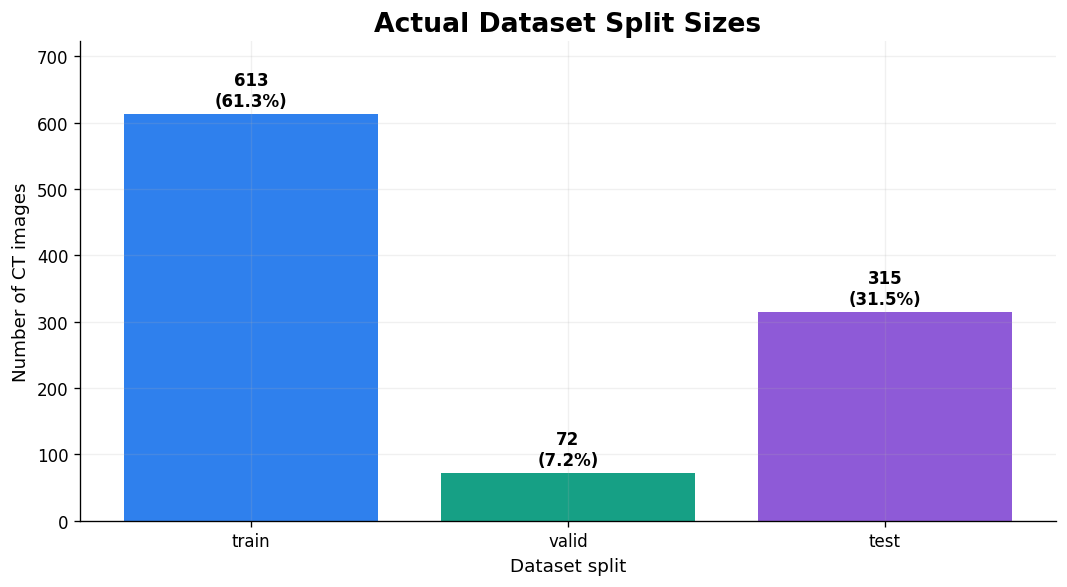

,images,percent
split,,
train,613,61.3
valid,72,7.2
test,315,31.5


In [16]:
# 6. EDA — actual train/valid/test split sizes
split_order=['train','valid','test']
counts=audit_df.split.value_counts().reindex(split_order).fillna(0).astype(int)
pct=counts/counts.sum()*100
fig,ax=plt.subplots(figsize=(9,5))
bars=ax.bar(counts.index,counts.values,color=[PALETTE['blue'],PALETTE['teal'],PALETTE['purple']])
ax.set(title='Actual Dataset Split Sizes',ylabel='Number of CT images',xlabel='Dataset split')
for b,n,p in zip(bars,counts.values,pct.values):
    ax.text(b.get_x()+b.get_width()/2,b.get_height()+max(counts)*.02,f'{n}\n({p:.1f}%)',ha='center',fontweight='bold')
ax.set_ylim(0,max(counts)*1.18); plt.tight_layout(); save_figure('eda_01_split_sizes'); plt.show()
display(pd.DataFrame({'images':counts,'percent':pct.round(2)}))

Saved: /kaggle/working/chest_ct_explainable_project/figures/eda_02_class_distribution.png


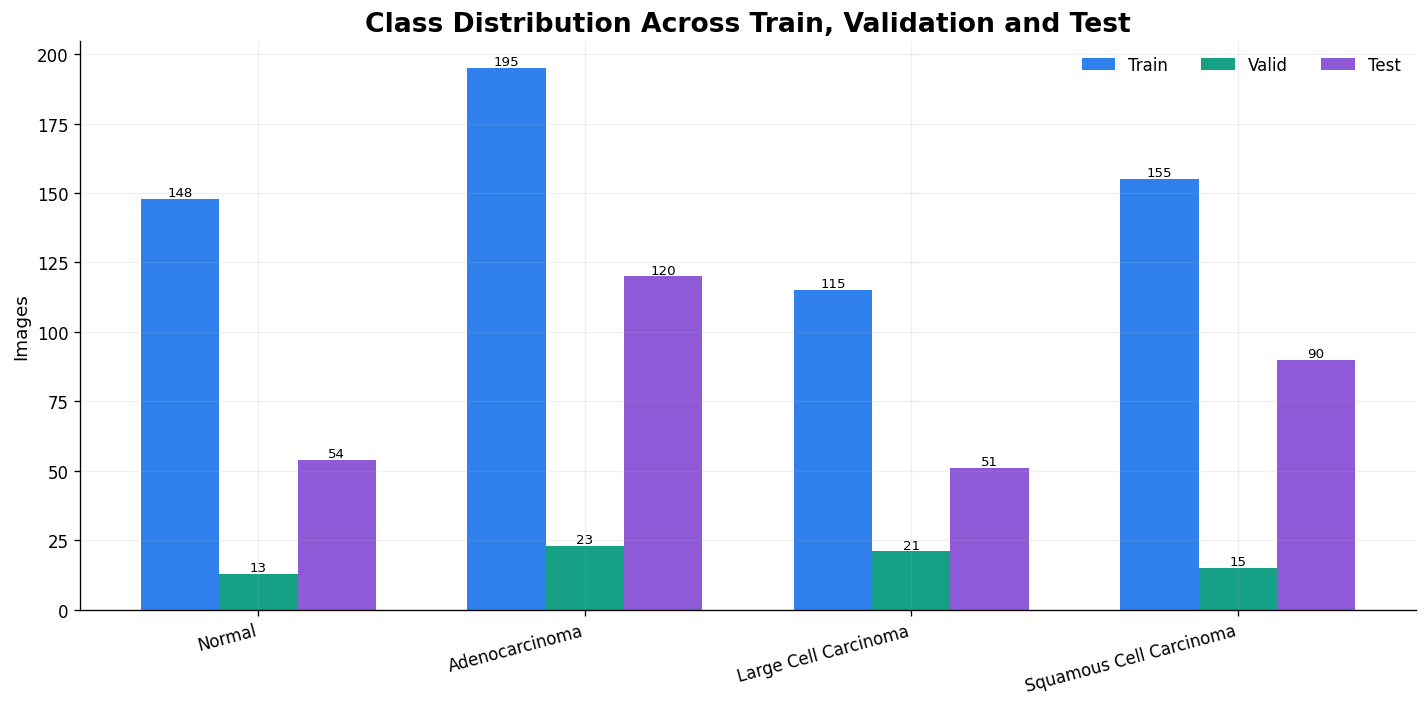

split,train,valid,test
label,,,
normal,148,13,54
adenocarcinoma,195,23,120
large_cell_carcinoma,115,21,51
squamous_cell_carcinoma,155,15,90


In [17]:
# 7. EDA — class distribution by split
class_split=(audit_df.groupby(['label','split']).size().unstack(fill_value=0)
             .reindex(CLASS_NAMES).reindex(columns=split_order))
x=np.arange(NUM_CLASSES); width=.24
fig,ax=plt.subplots(figsize=(12,6))
for j,(split,color) in enumerate(zip(split_order,[PALETTE['blue'],PALETTE['teal'],PALETTE['purple']])):
    bars=ax.bar(x+(j-1)*width,class_split[split],width,label=split.title(),color=color)
    for b in bars: ax.text(b.get_x()+b.get_width()/2,b.get_height()+1,str(int(b.get_height())),ha='center',fontsize=8)
ax.set(title='Class Distribution Across Train, Validation and Test',ylabel='Images')
ax.set_xticks(x); ax.set_xticklabels([c.replace('_',' ').title() for c in CLASS_NAMES],rotation=15,ha='right')
ax.legend(frameon=False,ncol=3); plt.tight_layout(); save_figure('eda_02_class_distribution'); plt.show()
display(class_split)

Saved: /kaggle/working/chest_ct_explainable_project/figures/eda_03_dimensions.png


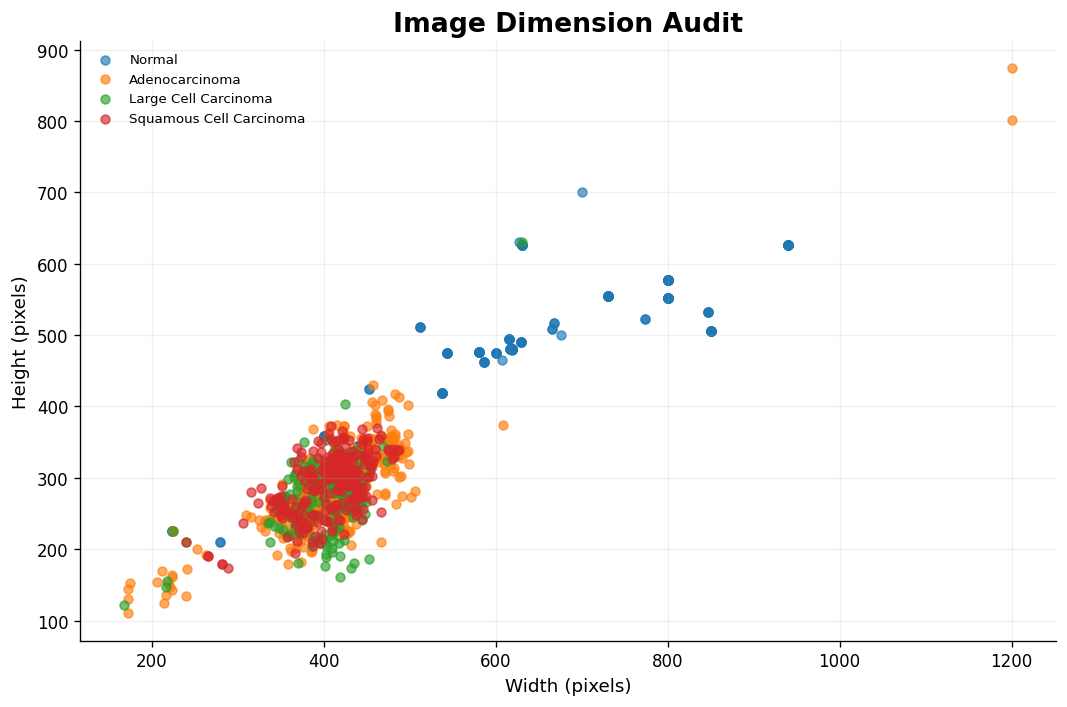

Saved: /kaggle/working/chest_ct_explainable_project/figures/eda_04_file_sizes.png


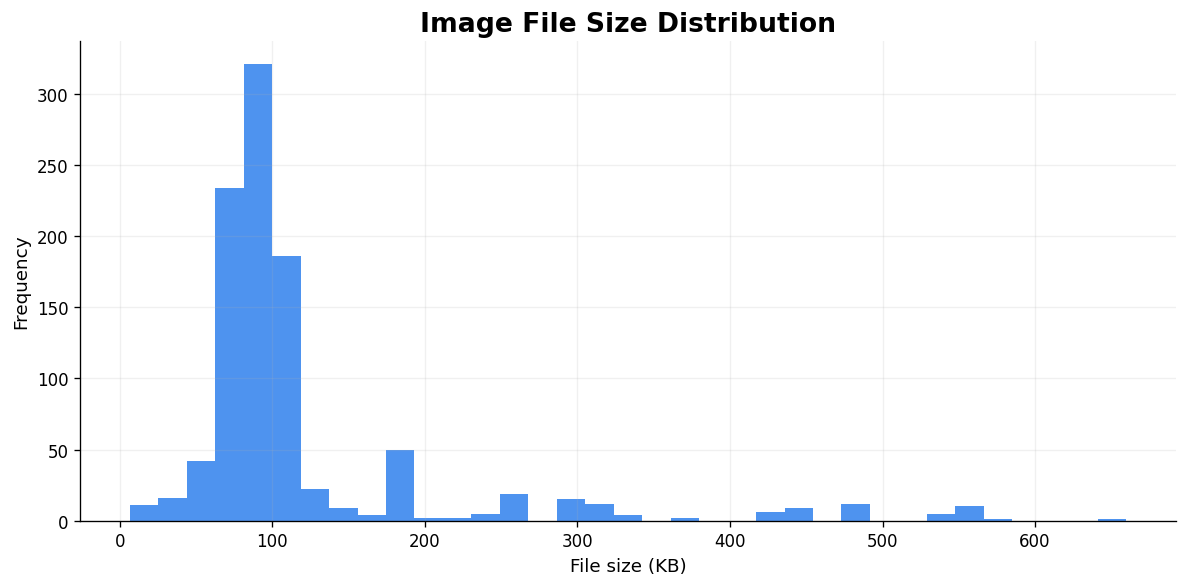

Saved: /kaggle/working/chest_ct_explainable_project/figures/eda_05_brightness.png


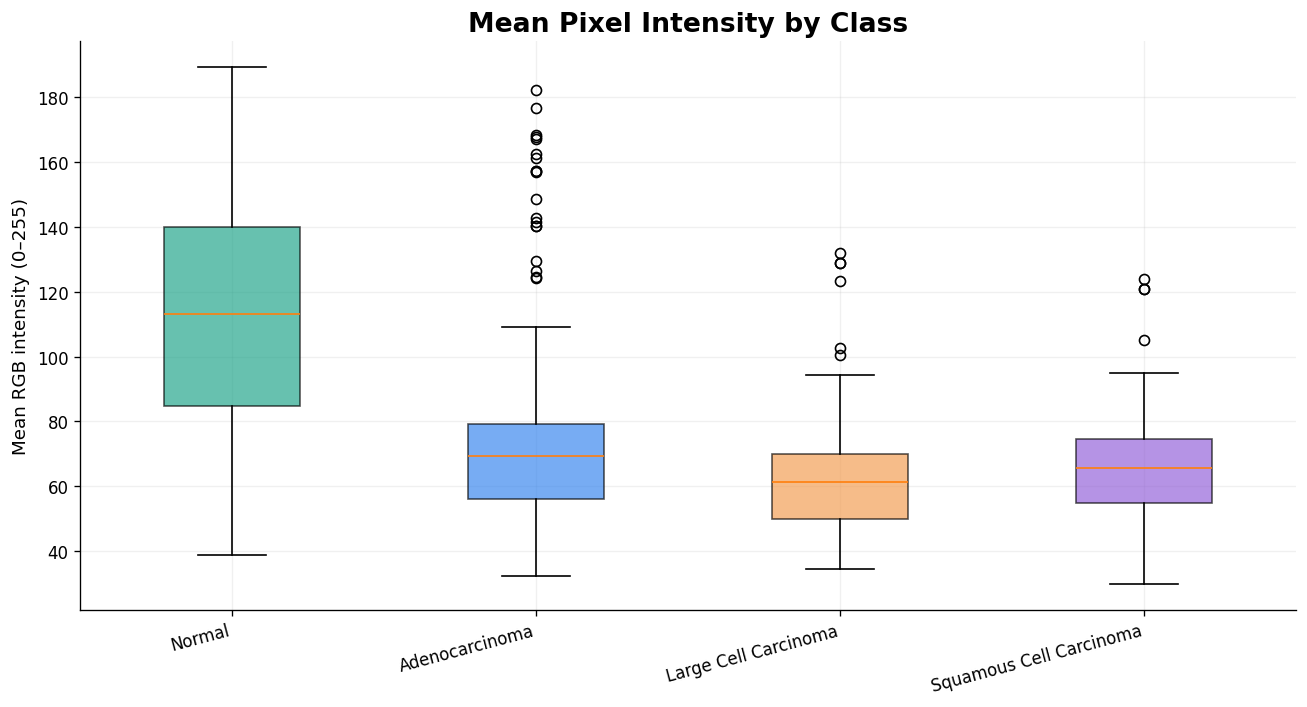

Saved: /kaggle/working/chest_ct_explainable_project/figures/eda_06_gallery.png


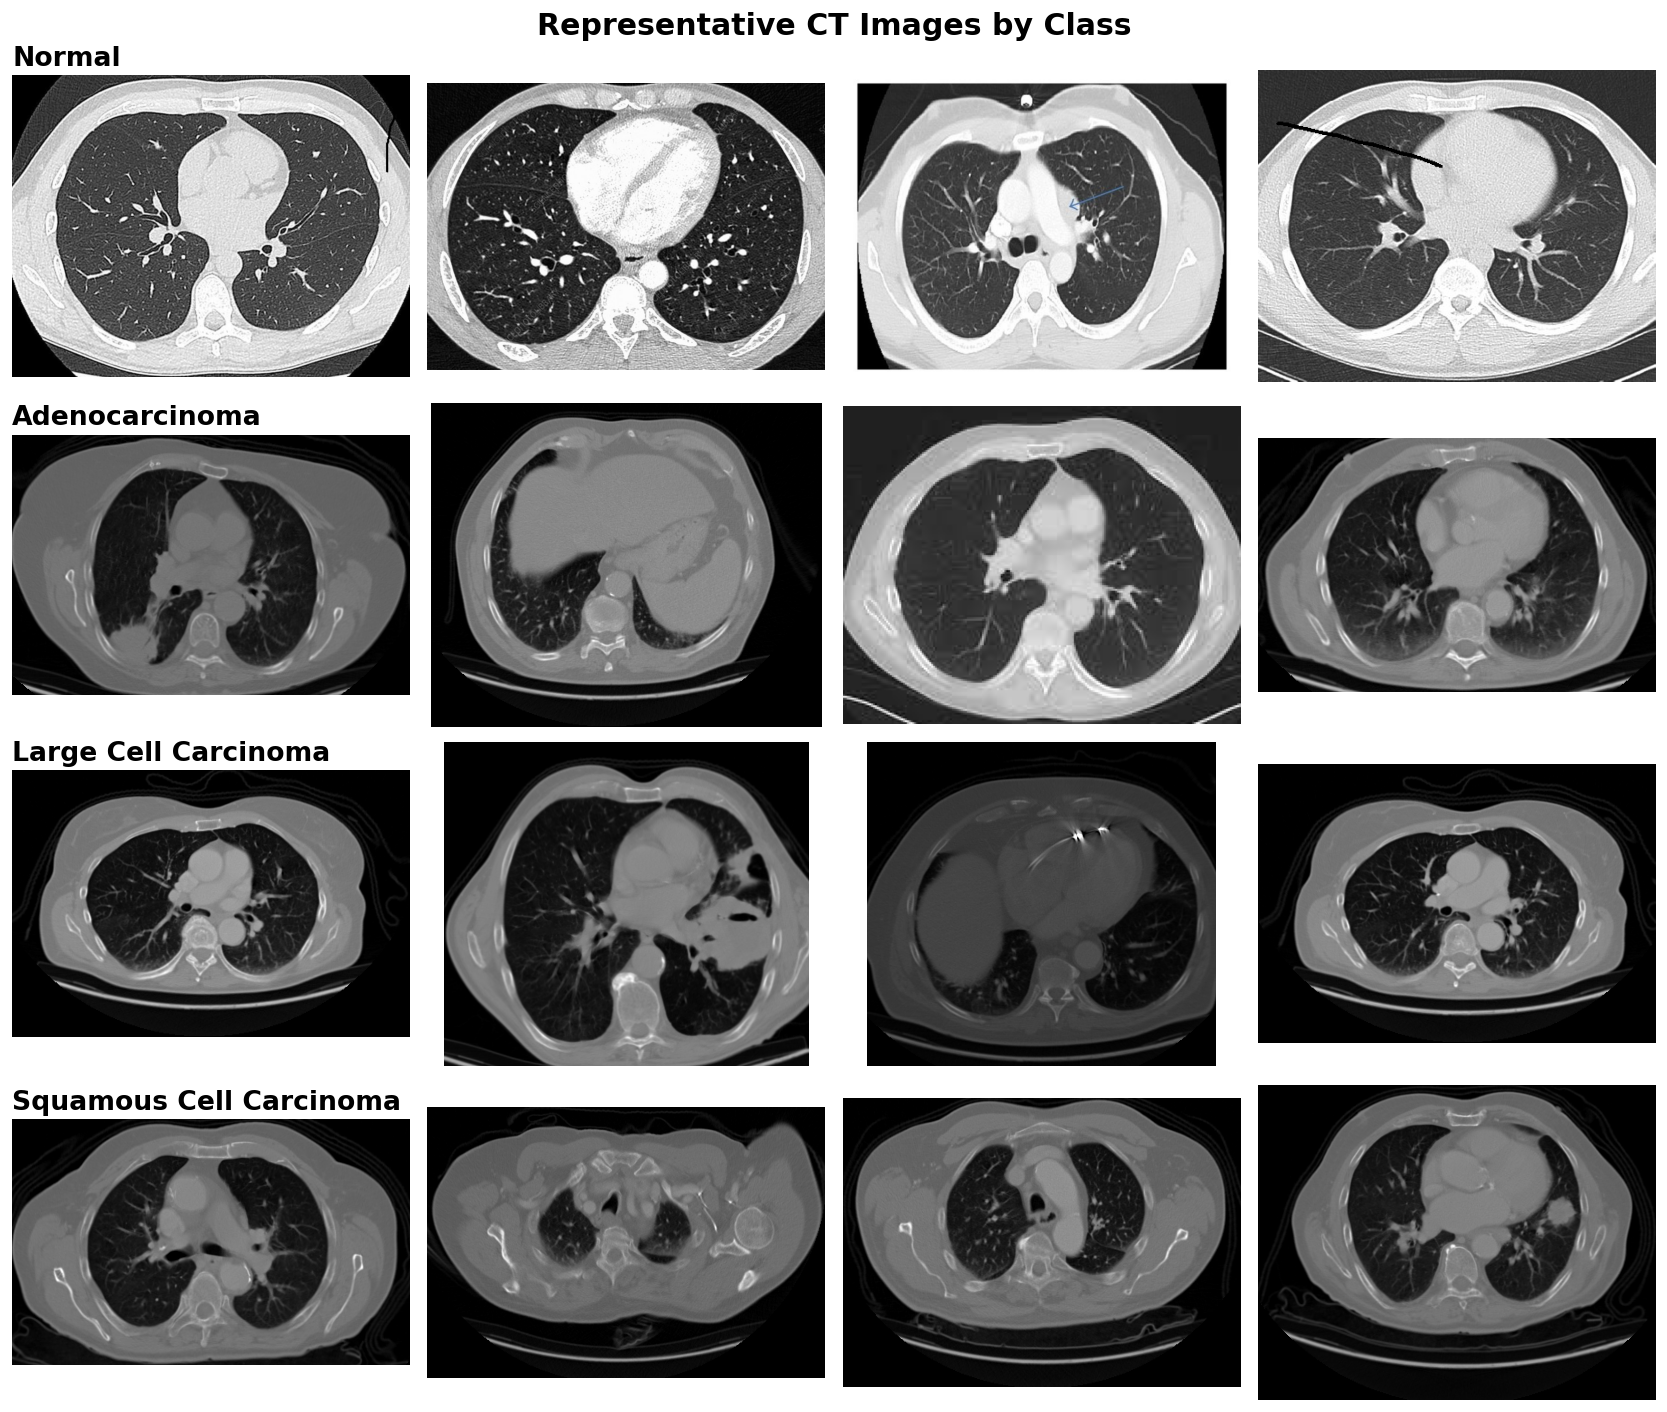

In [18]:
# 8. EDA — dimensions, file sizes, brightness and representative images
valid_meta=audit_df[~audit_df.corrupt].copy()
fig,ax=plt.subplots(figsize=(9,6))
for label in CLASS_NAMES:
    d=valid_meta[valid_meta.label==label]
    ax.scatter(d.width,d.height,s=28,alpha=.65,label=label.replace('_',' ').title())
ax.set(title='Image Dimension Audit',xlabel='Width (pixels)',ylabel='Height (pixels)'); ax.legend(frameon=False,fontsize=8)
plt.tight_layout(); save_figure('eda_03_dimensions'); plt.show()

fig,ax=plt.subplots(figsize=(10,5)); ax.hist(valid_meta.file_kb.dropna(),bins=35,color=PALETTE['blue'],alpha=.85)
ax.set(title='Image File Size Distribution',xlabel='File size (KB)',ylabel='Frequency')
plt.tight_layout(); save_figure('eda_04_file_sizes'); plt.show()

fig,ax=plt.subplots(figsize=(11,6)); data=[valid_meta.loc[valid_meta.label==c,'mean_intensity'].dropna().values for c in CLASS_NAMES]
bp=ax.boxplot(data,patch_artist=True,showfliers=True)
for patch,color in zip(bp['boxes'],[PALETTE['teal'],PALETTE['blue'],PALETTE['orange'],PALETTE['purple']]): patch.set_facecolor(color); patch.set_alpha(.65)
ax.set(title='Mean Pixel Intensity by Class',ylabel='Mean RGB intensity (0–255)')
ax.set_xticklabels([c.replace('_',' ').title() for c in CLASS_NAMES],rotation=15,ha='right')
plt.tight_layout(); save_figure('eda_05_brightness'); plt.show()

fig,axes=plt.subplots(NUM_CLASSES,4,figsize=(14,12))
for r,label in enumerate(CLASS_NAMES):
    chosen=valid_meta[valid_meta.label==label].sample(min(4,(valid_meta.label==label).sum()),random_state=SEED)
    for c in range(4):
        axes[r,c].axis('off')
        if c<len(chosen):
            item=chosen.iloc[c]
            with Image.open(item.path) as im: axes[r,c].imshow(im.convert('RGB'))
            if c==0: axes[r,c].set_title(label.replace('_',' ').title(),loc='left',fontweight='bold')
fig.suptitle('Representative CT Images by Class',fontsize=18,fontweight='bold'); plt.tight_layout(); save_figure('eda_06_gallery'); plt.show()

## 3. Leakage audit
Exact duplicates use SHA-256. Potential near-duplicates use a 64-bit dHash screen across different splits. **Patient-level leakage cannot be proven or excluded because patient identifiers are not supplied with these image folders; this limitation should be reported.**

In [19]:
# 9. Exact and perceptual cross-split duplicate reports
non_corrupt=audit_df[~audit_df.corrupt & audit_df.sha256.notna()].copy()
exact=[]
for sha,g in non_corrupt.groupby('sha256'):
    if len(g)>1:
        exact.append({'sha256':sha,'copies':len(g),'splits':', '.join(sorted(g.split.unique())),
                      'classes':', '.join(sorted(g.label.unique())),'cross_split':g.split.nunique()>1,
                      'label_conflict':g.label.nunique()>1})
exact_report=pd.DataFrame(exact,columns=['sha256','copies','splits','classes','cross_split','label_conflict'])
exact_report.to_csv(REPORT_DIR/'exact_duplicate_report.csv',index=False)
print('Exact duplicate groups:',len(exact_report))
print('Cross-split exact groups:',int(exact_report.cross_split.sum()) if len(exact_report) else 0)
display(exact_report.head(20))

def hamming(a,b): return int(a^b).bit_count()
items=non_corrupt[['path','filename','split','label','sha256','dhash_int']].to_dict('records')
near=[]
for i,a in enumerate(items):
    for b in items[i+1:]:
        if a['split']==b['split'] or a['sha256']==b['sha256']: continue
        dist=hamming(int(a['dhash_int']),int(b['dhash_int']))
        if dist<=NEAR_DUPLICATE_HAMMING_THRESHOLD:
            near.append({'split_a':a['split'],'class_a':a['label'],'file_a':a['path'],
                         'split_b':b['split'],'class_b':b['label'],'file_b':b['path'],'hamming_distance':dist})
near_report=pd.DataFrame(near)
near_report.to_csv(REPORT_DIR/'near_duplicate_cross_split_report.csv',index=False)
print('Potential cross-split near-duplicate pairs:',len(near_report)); display(near_report.head(20))

Exact duplicate groups: 59
Cross-split exact groups: 22


,sha256,copies,splits,classes,cross_split,label_conflict
0,00ce2ce4a6e3ce884ae03e072be37e0679be37e951c696...,2,train,normal,False,False
1,00e18662c33583d0e5016e6297d83a1b7183ed65b0a7ff...,4,"test, train",normal,True,False
2,01682f6b6c8905b4d67f24f0d1f6f3775215c639640640...,4,"test, train",normal,True,False
3,06c0583b34ba3aebc2741648787900f97144507f3703da...,2,train,normal,False,False
4,0ab902fe67ab45279ef35ae30b4e13ee82ea4f69ec3a2a...,4,"test, train",normal,True,False
5,1559e321220c9c7dbb54c04237975221605a28915af039...,2,train,normal,False,False
6,1a2c1e9aace95fb7d49ab58576794e3e2e298006fbd795...,4,train,normal,False,False
7,1f12429dd1f9884a356125bb5feae01a9042b214fefc9d...,5,"test, train, valid",normal,True,False
8,250c3163d199a0f76d55e18ed709fd7798b5ac3719d0fa...,4,"test, train",normal,True,False
9,259dce58ad0f977f039d04fb603703fea2e6a062ee0616...,4,train,normal,False,False


Potential cross-split near-duplicate pairs: 933


,split_a,class_a,file_a,split_b,class_b,file_b,hamming_distance
0,train,adenocarcinoma,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,valid,adenocarcinoma,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,4
1,train,adenocarcinoma,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,valid,squamous_cell_carcinoma,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,4
2,train,adenocarcinoma,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,valid,adenocarcinoma,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,5
3,train,adenocarcinoma,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,valid,adenocarcinoma,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,5
4,train,adenocarcinoma,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,valid,normal,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,4
5,train,adenocarcinoma,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,valid,normal,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,4
6,train,adenocarcinoma,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,test,normal,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,4
7,train,adenocarcinoma,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,test,normal,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,4
8,train,adenocarcinoma,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,test,normal,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,4
9,train,adenocarcinoma,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,test,normal,/kaggle/input/datasets/mohamedhanyyy/chest-cts...,4


Saved: /kaggle/working/chest_ct_explainable_project/figures/eda_07_leakage.png


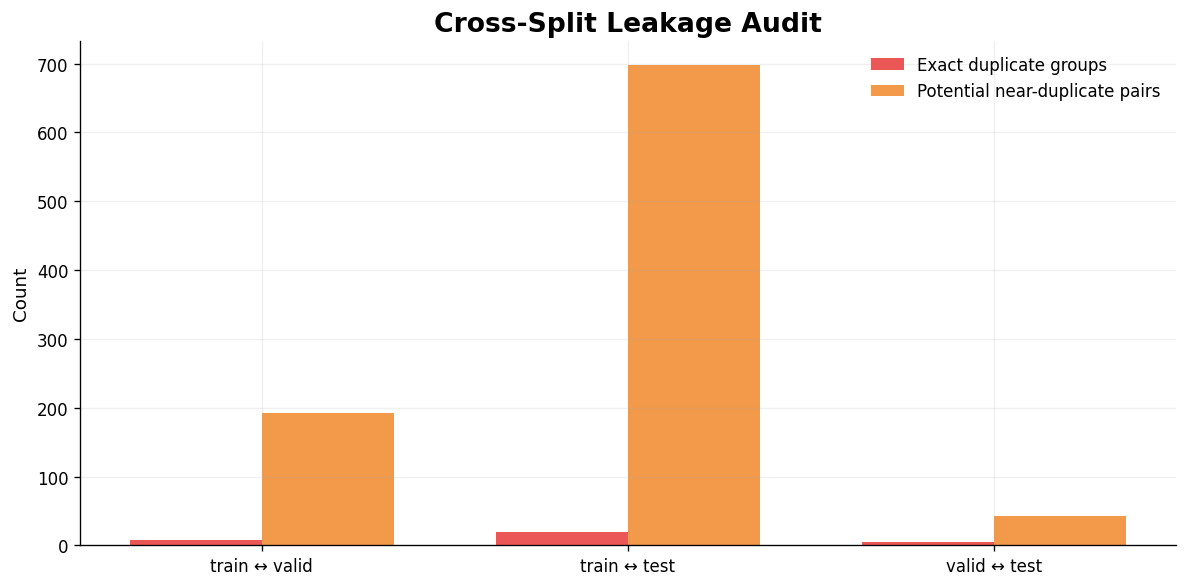

Exact duplicate copies removed: 153


label,adenocarcinoma,large_cell_carcinoma,normal,squamous_cell_carcinoma
split,,,,
test,120,51,8,90
train,194,115,55,152
valid,23,21,3,15


In [20]:
# 10. Leakage-control visual and modelling manifest
pairs=[('train','valid'),('train','test'),('valid','test')]
exact_counts={f'{a} ↔ {b}':0 for a,b in pairs}
for sha,g in non_corrupt.groupby('sha256'):
    s=set(g.split)
    for a,b in pairs:
        if a in s and b in s: exact_counts[f'{a} ↔ {b}']+=1
near_counts={k:0 for k in exact_counts}
if len(near_report):
    for _,r in near_report.iterrows():
        s={r.split_a,r.split_b}
        for a,b in pairs:
            if s=={a,b}: near_counts[f'{a} ↔ {b}']+=1
labels=list(exact_counts); x=np.arange(len(labels))
fig,ax=plt.subplots(figsize=(10,5)); ax.bar(x-.18,[exact_counts[k] for k in labels],.36,label='Exact duplicate groups',color=PALETTE['red'])
ax.bar(x+.18,[near_counts[k] for k in labels],.36,label='Potential near-duplicate pairs',color=PALETTE['orange'])
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set(title='Cross-Split Leakage Audit',ylabel='Count'); ax.legend(frameon=False)
plt.tight_layout(); save_figure('eda_07_leakage'); plt.show()

clean_manifest=audit_df[~audit_df.corrupt].copy()
if STRICT_LEAKAGE_CONTROL:
    priority={'train':0,'valid':1,'test':2}; clean_manifest['priority']=clean_manifest.split.map(priority)
    before=len(clean_manifest)
    clean_manifest=(clean_manifest.sort_values(['sha256','priority','path']).drop_duplicates('sha256',keep='first')
                    .drop(columns='priority').reset_index(drop=True))
    print('Exact duplicate copies removed:',before-len(clean_manifest))
clean_manifest.to_csv(REPORT_DIR/'dataset_manifest_modelling.csv',index=False)
display(clean_manifest.groupby(['split','label']).size().unstack(fill_value=0))

## 4. Input pipeline and conservative augmentation
All saved models accept 224×224 RGB arrays on the 0–255 scale and contain their own preprocessing. Validation/test data are never augmented.

I0000 00:00:1786557840.117156      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786557840.119915      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Class weights: {0: 2.3454545454545452, 1: 0.6649484536082474, 2: 1.1217391304347826, 3: 0.8486842105263158}
Saved: /kaggle/working/chest_ct_explainable_project/figures/eda_08_augmentation.png


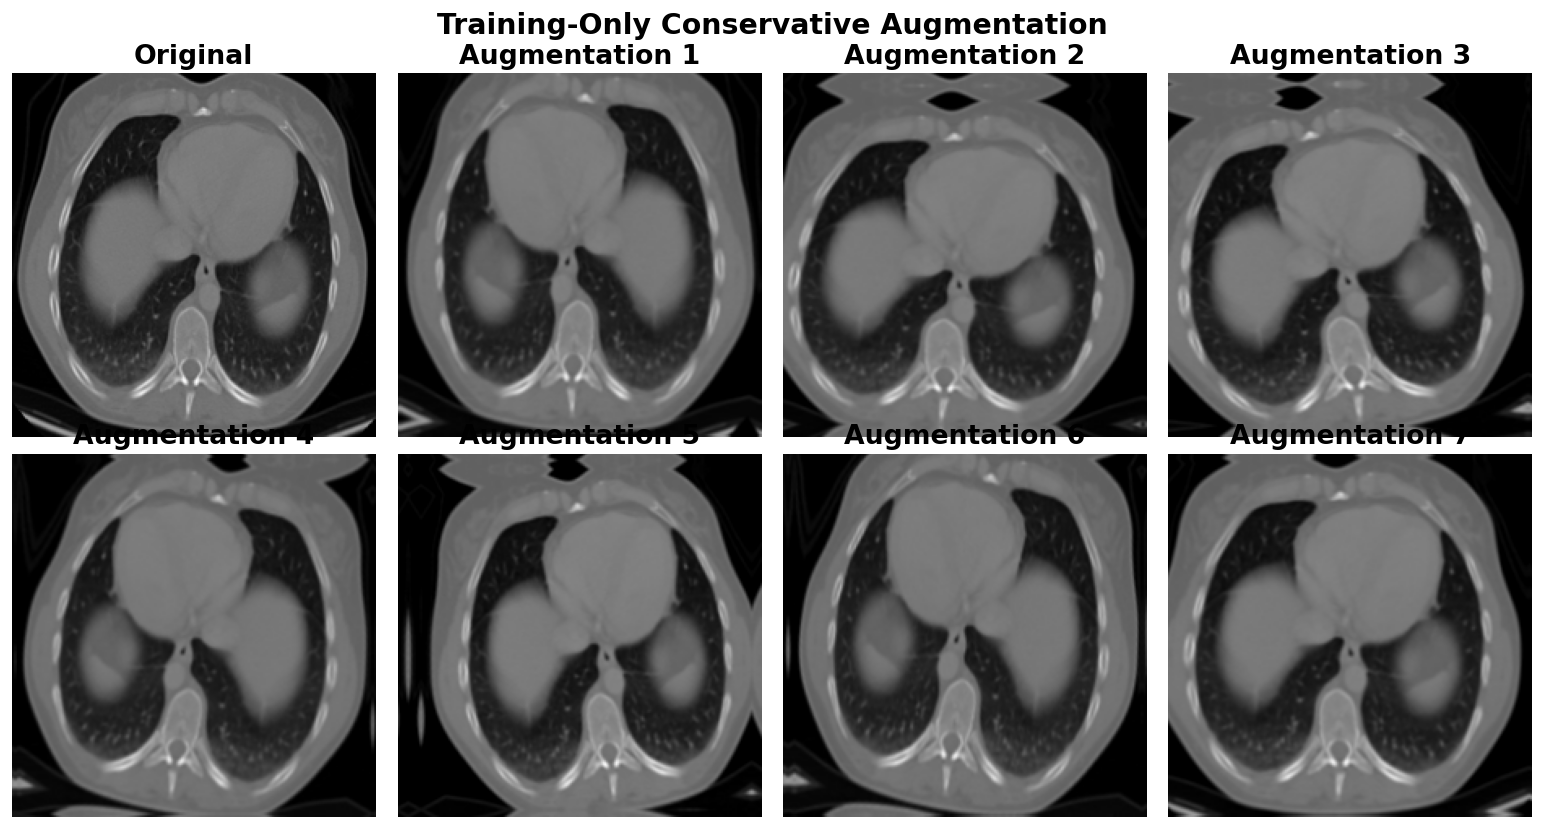

In [21]:
# 11. tf.data pipeline, class weights and augmentation preview
def load_tensor(path,label_idx):
    b=tf.io.read_file(path); img=tf.io.decode_image(b,channels=3,expand_animations=False); img.set_shape([None,None,3])
    img=tf.image.resize(img,IMG_SIZE,antialias=True); img=tf.cast(img,tf.float32)
    return img,tf.one_hot(label_idx,NUM_CLASSES)
def make_ds(df,training=False):
    ds=tf.data.Dataset.from_tensor_slices((df.path.astype(str).to_numpy(),df.label_idx.astype(np.int32).to_numpy()))
    if training: ds=ds.shuffle(len(df),seed=SEED,reshuffle_each_iteration=True)
    return ds.map(load_tensor,num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
train_df=clean_manifest[clean_manifest.split=='train'].reset_index(drop=True)
valid_df=clean_manifest[clean_manifest.split=='valid'].reset_index(drop=True)
test_df=clean_manifest[clean_manifest.split=='test'].reset_index(drop=True)
train_ds=make_ds(train_df,True); train_eval_ds=make_ds(train_df,False); valid_ds=make_ds(valid_df,False); test_ds=make_ds(test_df,False)
weights=compute_class_weight('balanced',classes=np.arange(NUM_CLASSES),y=train_df.label_idx.to_numpy())
CLASS_WEIGHTS={i:float(w) for i,w in enumerate(weights)}
print('Class weights:',CLASS_WEIGHTS)

data_augmentation=keras.Sequential([
    layers.RandomFlip('horizontal',seed=SEED),layers.RandomRotation(.035,fill_mode='reflect',seed=SEED),
    layers.RandomTranslation(.05,.05,fill_mode='reflect',seed=SEED),layers.RandomZoom(.08,.08,fill_mode='reflect',seed=SEED),
    layers.RandomContrast(.10,seed=SEED)],name='training_augmentation')

sample_path=train_df.iloc[0].path
with Image.open(sample_path) as im: original=np.asarray(im.convert('RGB').resize(IMG_SIZE),dtype=np.float32)
fig,axes=plt.subplots(2,4,figsize=(13,7)); axes=axes.ravel(); axes[0].imshow(original.astype(np.uint8)); axes[0].set_title('Original'); axes[0].axis('off')
batch=tf.expand_dims(original,0)
for i in range(1,8):
    aug=data_augmentation(batch,training=True)[0].numpy(); axes[i].imshow(np.clip(aug,0,255).astype(np.uint8)); axes[i].set_title(f'Augmentation {i}'); axes[i].axis('off')
fig.suptitle('Training-Only Conservative Augmentation',fontsize=17,fontweight='bold'); plt.tight_layout(); save_figure('eda_08_augmentation'); plt.show()

## 5. Three model candidates
A compact original CNN provides the baseline. EfficientNetB0 and DenseNet121 use ImageNet transfer learning with a two-stage freeze/fine-tune strategy. Each architecture exposes a top-level `gradcam_target` convolutional layer.

In [22]:
# 12. Model builders
@keras.utils.register_keras_serializable(package='ChestCT')
class DenseNetInputTransform(layers.Layer):
    def call(self,inputs): return keras.applications.densenet.preprocess_input(inputs)
    def get_config(self): return super().get_config()

def head(x,drop=.35):
    x=layers.Conv2D(256,1,padding='same',activation='relu',kernel_initializer='he_normal',name='gradcam_target')(x)
    x=layers.GlobalAveragePooling2D()(x); x=layers.BatchNormalization()(x); x=layers.Dropout(drop,seed=SEED)(x)
    x=layers.Dense(128,activation='relu')(x); x=layers.Dropout(drop*.75,seed=SEED+1)(x)
    return layers.Dense(NUM_CLASSES,activation='softmax',name='class_probabilities')(x)

def build_custom_cnn():
    inp=keras.Input((*IMG_SIZE,3),name='ct_image'); x=data_augmentation(inp); x=layers.Rescaling(1./255)(x)
    for filters,drop in [(32,.10),(64,.15),(128,.20)]:
        for _ in range(2):
            x=layers.SeparableConv2D(filters,3,padding='same',use_bias=False)(x); x=layers.BatchNormalization()(x); x=layers.Activation('relu')(x)
        x=layers.MaxPooling2D()(x); x=layers.Dropout(drop,seed=SEED)(x)
    x=layers.Conv2D(192,3,padding='same',activation='relu',name='gradcam_target')(x); x=layers.GlobalAveragePooling2D()(x)
    x=layers.Dropout(.35,seed=SEED)(x); x=layers.Dense(128,activation='relu')(x); x=layers.Dropout(.25,seed=SEED+1)(x)
    return keras.Model(inp,layers.Dense(NUM_CLASSES,activation='softmax',name='class_probabilities')(x),name='custom_cnn'),None

def build_efficientnetb0():
    inp=keras.Input((*IMG_SIZE,3),name='ct_image'); x=data_augmentation(inp)
    base=keras.applications.EfficientNetB0(include_top=False,weights='imagenet',input_shape=(*IMG_SIZE,3)); base.trainable=False
    return keras.Model(inp,head(base(x,training=False),.35),name='efficientnetb0'),base

def build_densenet121():
    inp=keras.Input((*IMG_SIZE,3),name='ct_image'); x=data_augmentation(inp); x=DenseNetInputTransform(name='densenet_preprocess')(x)
    base=keras.applications.DenseNet121(include_top=False,weights='imagenet',input_shape=(*IMG_SIZE,3)); base.trainable=False
    return keras.Model(inp,head(base(x,training=False),.40),name='densenet121'),base

BUILDERS={'custom_cnn':build_custom_cnn,'efficientnetb0':build_efficientnetb0,'densenet121':build_densenet121}

In [23]:
# 13. Macro-F1 callback, metrics and training helpers
VALID_Y=valid_df.label_idx.to_numpy()
class ValidationMacroF1(keras.callbacks.Callback):
    def __init__(self,ds,y): super().__init__(); self.ds=ds; self.y=np.asarray(y)
    def on_epoch_end(self,epoch,logs=None):
        probs=self.model.predict(self.ds,verbose=0); score=f1_score(self.y,np.argmax(probs,axis=1),average='macro',zero_division=0)
        if logs is not None: logs['val_macro_f1']=float(score)
        print(f' — val_macro_f1: {score:.4f}')

def compile_model(model,lr):
    model.compile(optimizer=keras.optimizers.Adam(lr),loss=keras.losses.CategoricalCrossentropy(label_smoothing=.03),metrics=[keras.metrics.CategoricalAccuracy(name='accuracy')])
def callbacks(path,patience=5):
    return [ValidationMacroF1(valid_ds,VALID_Y),
            keras.callbacks.ModelCheckpoint(path,monitor='val_macro_f1',mode='max',save_best_only=True,verbose=1),
            keras.callbacks.EarlyStopping(monitor='val_macro_f1',mode='max',patience=patience,restore_best_weights=True,verbose=1),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=.35,patience=2,min_lr=1e-7,verbose=1)]
def history_df(hist,phase):
    d=pd.DataFrame(hist.history); d['epoch']=np.arange(1,len(d)+1); d['phase']=phase; return d

def fine_tune_backbone(base,last_n=35):
    base.trainable=True; cutoff=max(0,len(base.layers)-last_n)
    for i,layer in enumerate(base.layers): layer.trainable=(i>=cutoff and not isinstance(layer,layers.BatchNormalization))

def metric_summary(y,probs):
    pred=np.argmax(probs,axis=1)
    p,r,f,_=precision_recall_fscore_support(y,pred,average='macro',zero_division=0)
    _,_,fw,_=precision_recall_fscore_support(y,pred,average='weighted',zero_division=0)
    onehot=label_binarize(y,classes=np.arange(NUM_CLASSES))
    try: roc=roc_auc_score(onehot,probs,average='macro',multi_class='ovr')
    except ValueError: roc=np.nan
    return {'accuracy':accuracy_score(y,pred),'balanced_accuracy':balanced_accuracy_score(y,pred),
            'macro_precision':p,'macro_recall':r,'macro_f1':f,'weighted_f1':fw,'macro_roc_auc_ovr':roc}

## 6. Train candidates using validation data only
Transfer models are first trained with frozen backbones and then fine-tuned with a low learning rate. Phase checkpoints and architecture candidates are compared only on the validation set.

In [24]:
# 14. Train all candidates
candidate_records=[]; history_frames=[]
for name,builder in BUILDERS.items():
    print('\n'+'='*88+'\nTRAINING '+name+'\n'+'='*88)
    keras.backend.clear_session(); gc.collect(); model,base=builder(); params=model.count_params(); phase_paths=[]
    model.summary()
    if name=='custom_cnn':
        compile_model(model,3e-4); p=MODEL_DIR/f'{name}_custom.keras'
        h=model.fit(train_ds,validation_data=valid_ds,epochs=CUSTOM_EPOCHS,class_weight=CLASS_WEIGHTS,callbacks=callbacks(p,6),verbose=1)
        history_frames.append(history_df(h,f'{name}_custom')); phase_paths.append(('custom',p))
    else:
        compile_model(model,4e-4); p1=MODEL_DIR/f'{name}_head.keras'
        h1=model.fit(train_ds,validation_data=valid_ds,epochs=HEAD_EPOCHS,class_weight=CLASS_WEIGHTS,callbacks=callbacks(p1,4),verbose=1)
        history_frames.append(history_df(h1,f'{name}_head')); phase_paths.append(('head',p1))
        model=keras.models.load_model(p1,custom_objects={'DenseNetInputTransform':DenseNetInputTransform})
        key='efficientnet' if name=='efficientnetb0' else 'densenet'
        base=next(l for l in model.layers if isinstance(l,keras.Model) and key in l.name.lower())
        fine_tune_backbone(base,FINE_TUNE_LAYERS); compile_model(model,1e-5); p2=MODEL_DIR/f'{name}_finetune.keras'
        h2=model.fit(train_ds,validation_data=valid_ds,epochs=FINETUNE_EPOCHS,class_weight=CLASS_WEIGHTS,callbacks=callbacks(p2,4),verbose=1)
        history_frames.append(history_df(h2,f'{name}_finetune')); phase_paths.append(('finetune',p2))
    scored=[]
    for phase,path in phase_paths:
        m=keras.models.load_model(path,custom_objects={'DenseNetInputTransform':DenseNetInputTransform})
        metrics=metric_summary(VALID_Y,m.predict(valid_ds,verbose=0)); scored.append((phase,path,metrics)); print(phase,metrics)
        del m; keras.backend.clear_session(); gc.collect()
    best=max(scored,key=lambda z:z[2]['macro_f1']); final=MODEL_DIR/f'{name}_best.keras'; shutil.copy2(best[1],final)
    candidate_records.append({'model':name,'best_phase':best[0],'checkpoint':str(final),'parameters':int(params),**{f'val_{k}':float(v) for k,v in best[2].items()}})

candidate_table=pd.DataFrame(candidate_records).sort_values(['val_macro_f1','val_balanced_accuracy'],ascending=False).reset_index(drop=True)
candidate_table.to_csv(REPORT_DIR/'validation_model_comparison.csv',index=False); display(candidate_table)


TRAINING custom_cnn


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ct_image (InputLayer)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 224, 224, 32)   │           123 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 224, 224, 32)   │         1,312 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 112, 112, 64)   │         2,336 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 112, 112, 64)   │         4,672 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 56, 56, 128)    │         8,768 │
│ (SeparableConv2D)               │                        │             

 Total params: 283,135 (1.08 MB)

 Trainable params: 282,239 (1.08 MB)

...

 Total params: 7,334,340 (27.98 MB)

 Trainable params: 296,324 (1.13 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

Epoch 1/14
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.3333 - loss: 1.8488 — val_macro_f1: 0.1650

Epoch 1: val_macro_f1 improved from None to 0.16500, saving model to /kaggle/working/chest_ct_explainable_project/models/densenet121_head.keras

Epoch 1: finished saving model to /kaggle/working/chest_ct_explainable_project/models/densenet121_head.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.3721 - loss: 1.6807 - val_accuracy: 0.2903 - val_loss: 1.3640 - val_macro_f1: 0.1650 - learning_rate: 4.0000e-04
Epoch 2/14
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.4316 - loss: 1.3422 — val_macro_f1: 0.1792

Epoch 2: val_macro_f1 improved from 0.16500 to 0.17916, saving model to /kaggle/working/chest_ct_explainable_project/models/densenet121_head.keras

Epoch 2: finished saving model to /kaggle/working/chest_ct_explainable_project/models/densenet121_head.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 280ms/step - accuracy: 0.4806 - loss: 1.2210 - val_accuracy: 0.2903 - val

,model,best_phase,checkpoint,parameters,val_accuracy,val_balanced_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_f1,val_macro_roc_auc_ovr
0,efficientnetb0,finetune,/kaggle/working/chest_ct_explainable_project/m...,4411943,0.725806,0.718116,0.813447,0.718116,0.743013,0.734968,0.908393
1,densenet121,finetune,/kaggle/working/chest_ct_explainable_project/m...,7334340,0.661290,0.733437,0.632310,0.733437,0.658658,0.664754,0.859470
2,custom_cnn,custom,/kaggle/working/chest_ct_explainable_project/m...,283135,0.241935,0.250000,0.060484,0.250000,0.097403,0.094261,0.561663


Saved: /kaggle/working/chest_ct_explainable_project/figures/training_custom_cnn.png


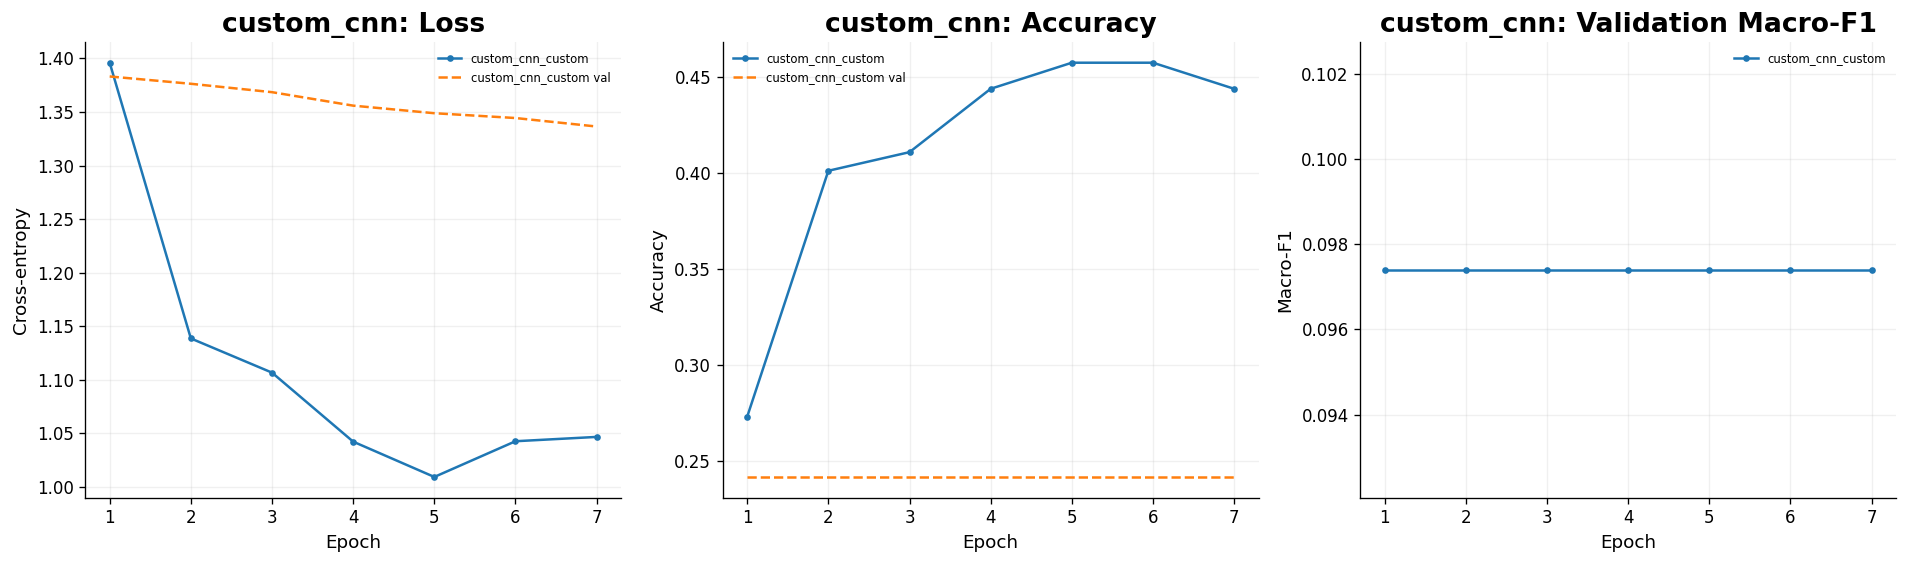

Saved: /kaggle/working/chest_ct_explainable_project/figures/training_efficientnetb0.png


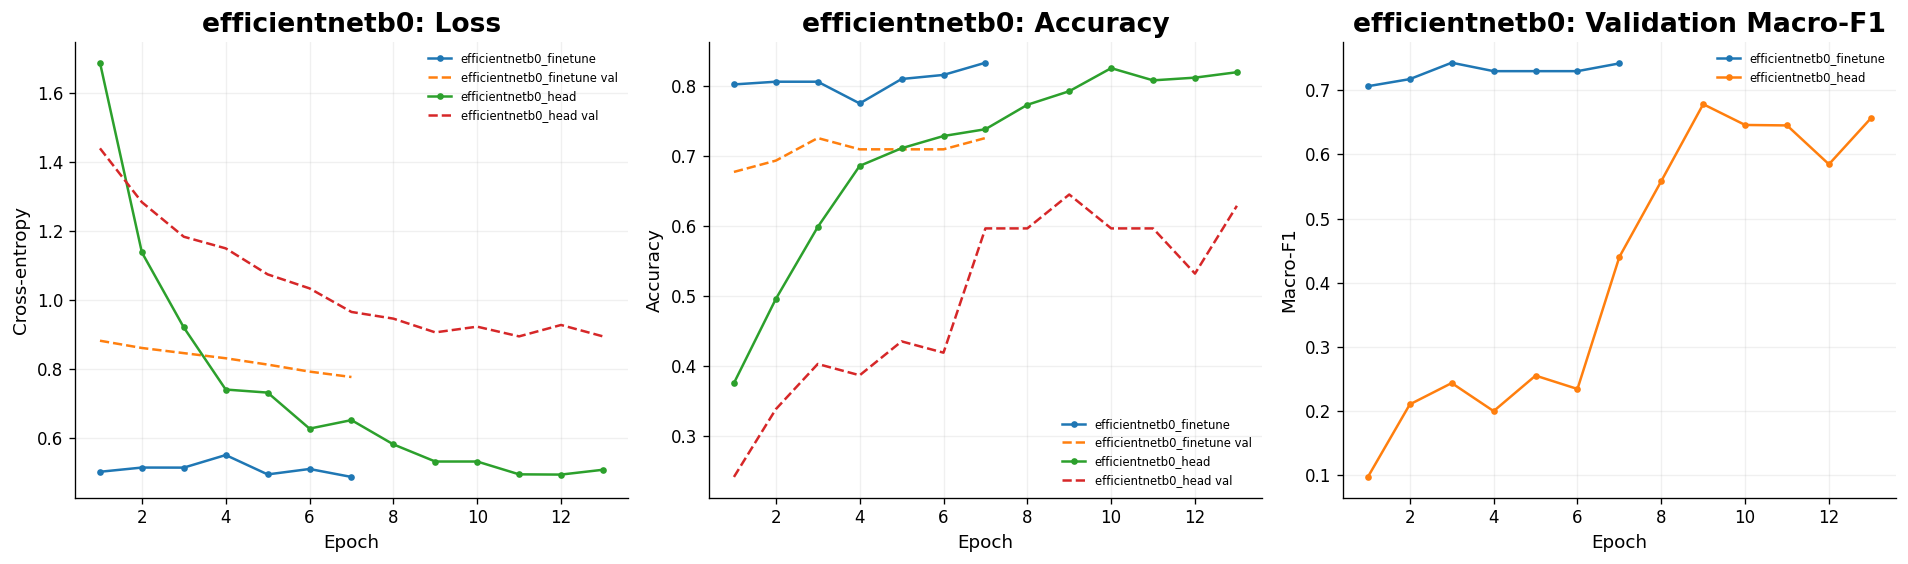

Saved: /kaggle/working/chest_ct_explainable_project/figures/training_densenet121.png


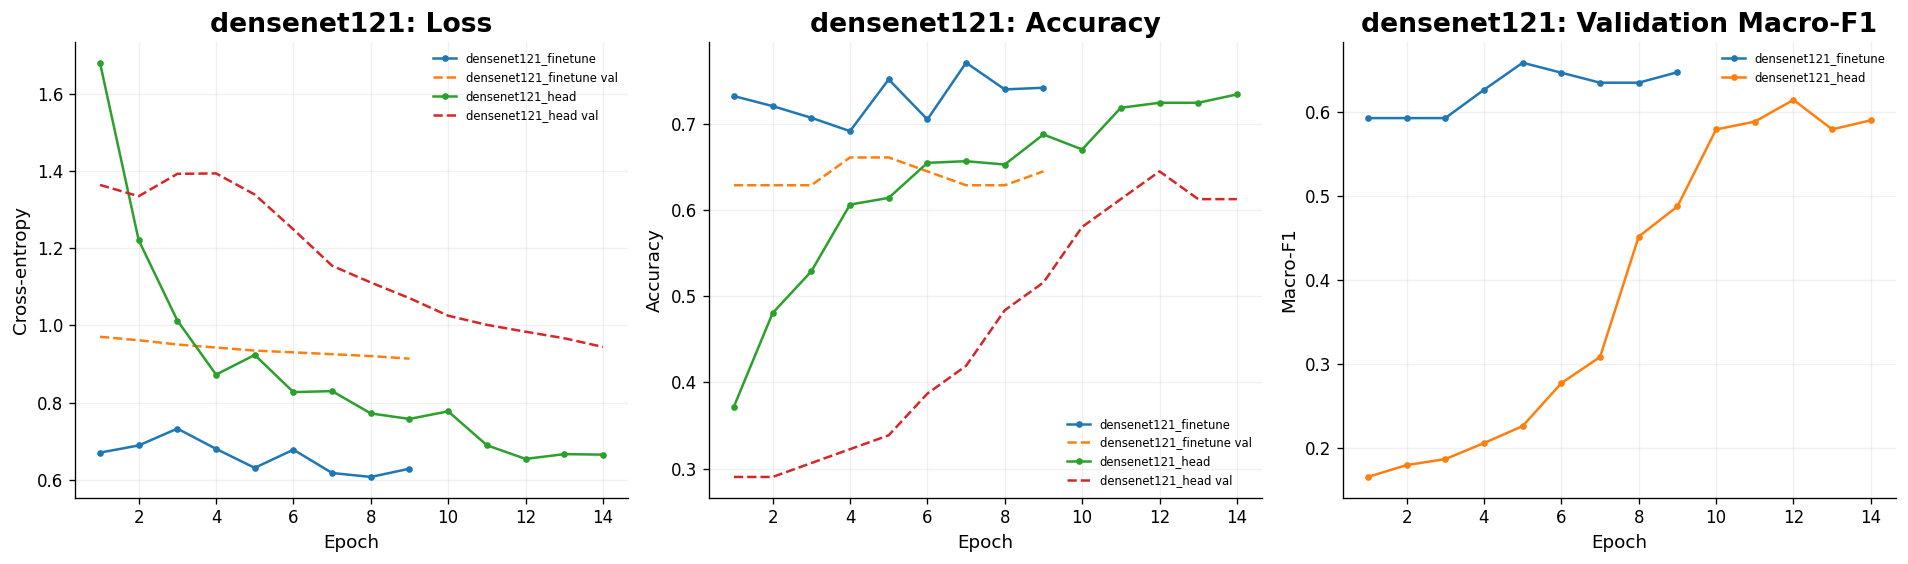

Saved: /kaggle/working/chest_ct_explainable_project/figures/model_comparison_validation.png


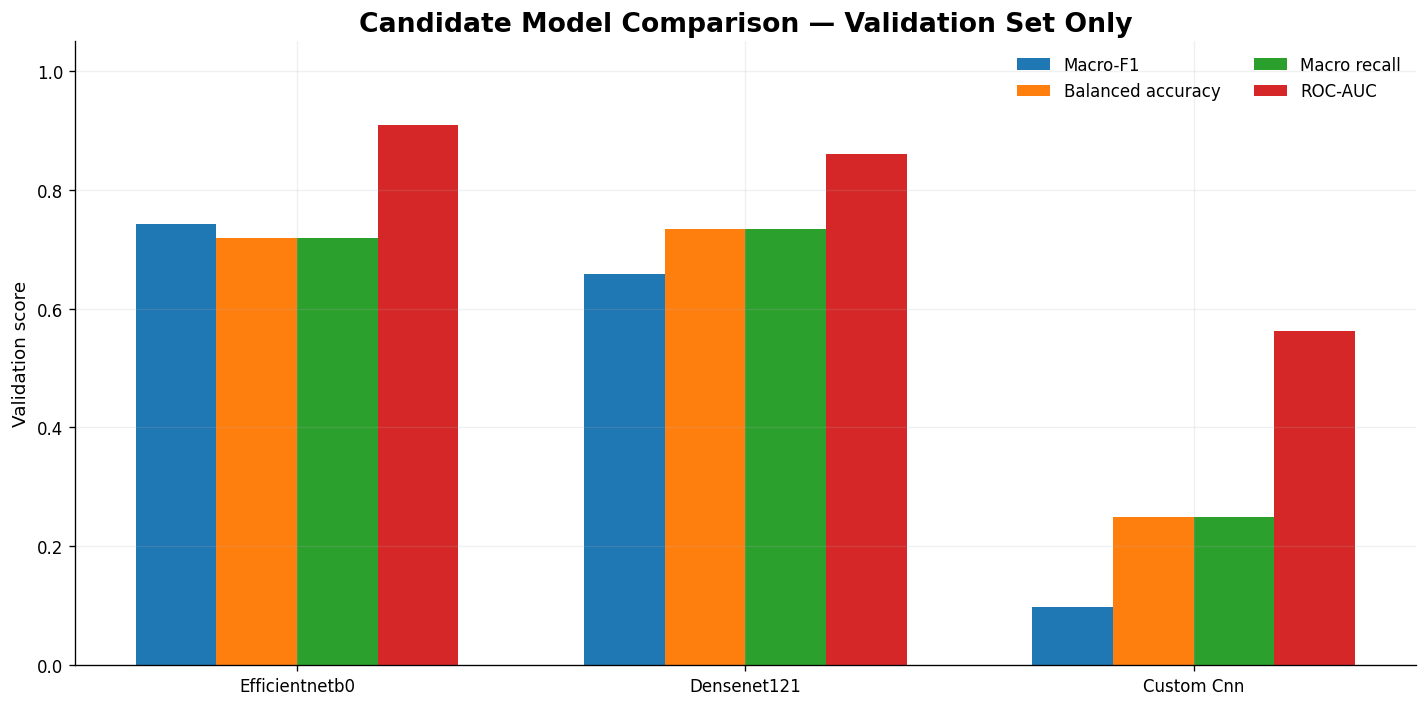

Saved: /kaggle/working/chest_ct_explainable_project/figures/model_parameter_comparison.png


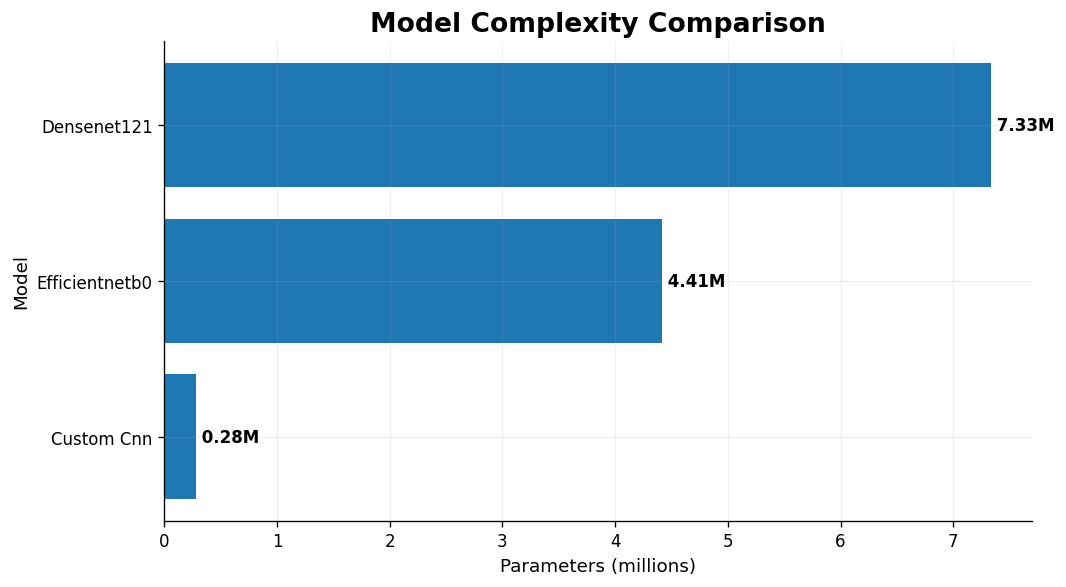

In [25]:
# 15. Training curves and validation comparison
all_history=pd.concat(history_frames,ignore_index=True); all_history.to_csv(REPORT_DIR/'training_history_all_models.csv',index=False)
for name in BUILDERS:
    d=all_history[all_history.phase.str.startswith(name)]
    fig,axes=plt.subplots(1,3,figsize=(16,4.8))
    for phase,g in d.groupby('phase'):
        e=np.arange(1,len(g)+1); axes[0].plot(e,g.loss,marker='o',ms=3,label=phase); axes[0].plot(e,g.val_loss,'--',label=phase+' val')
        axes[1].plot(e,g.accuracy,marker='o',ms=3,label=phase); axes[1].plot(e,g.val_accuracy,'--',label=phase+' val')
        if 'val_macro_f1' in g: axes[2].plot(e,g.val_macro_f1,marker='o',ms=3,label=phase)
    for ax,title,y in zip(axes,['Loss','Accuracy','Validation Macro-F1'],['Cross-entropy','Accuracy','Macro-F1']):
        ax.set(title=f'{name}: {title}',xlabel='Epoch',ylabel=y); ax.legend(frameon=False,fontsize=7)
    plt.tight_layout(); save_figure('training_'+name); plt.show()

cols=[('val_macro_f1','Macro-F1'),('val_balanced_accuracy','Balanced accuracy'),('val_macro_recall','Macro recall'),('val_macro_roc_auc_ovr','ROC-AUC')]
x=np.arange(len(candidate_table)); width=.18; fig,ax=plt.subplots(figsize=(12,6))
for j,(col,label) in enumerate(cols): ax.bar(x+(j-1.5)*width,candidate_table[col],width,label=label)
ax.set_xticks(x); ax.set_xticklabels(candidate_table.model.str.replace('_',' ').str.title()); ax.set_ylim(0,1.05)
ax.set(title='Candidate Model Comparison — Validation Set Only',ylabel='Validation score'); ax.legend(frameon=False,ncol=2)
plt.tight_layout(); save_figure('model_comparison_validation'); plt.show()

fig,ax=plt.subplots(figsize=(9,5))
complexity=candidate_table.sort_values('parameters')
ax.barh(complexity.model.str.replace('_',' ').str.title(), complexity.parameters/1e6)
ax.set(title='Model Complexity Comparison',xlabel='Parameters (millions)',ylabel='Model')
for i,v in enumerate(complexity.parameters/1e6): ax.text(v,i,f' {v:.2f}M',va='center',fontweight='bold')
plt.tight_layout(); save_figure('model_parameter_comparison'); plt.show()

## 7. Lock the model, then evaluate the held-out test set once
The final model is selected by validation macro-F1 (balanced accuracy is the tie-breaker). Only after this selection is frozen do we calculate formal test metrics.

In [26]:
# 16. Final selection and one-time test evaluation
candidate_table=candidate_table.sort_values(['val_macro_f1','val_balanced_accuracy'],ascending=False).reset_index(drop=True)
SELECTED_MODEL_NAME=candidate_table.loc[0,'model']; SELECTED_MODEL_PATH=Path(candidate_table.loc[0,'checkpoint'])
print('Selected:',SELECTED_MODEL_NAME,'| val macro-F1:',candidate_table.loc[0,'val_macro_f1'])
selected_model=keras.models.load_model(SELECTED_MODEL_PATH,custom_objects={'DenseNetInputTransform':DenseNetInputTransform})
TEST_Y=test_df.label_idx.to_numpy(); TEST_PROBS=selected_model.predict(test_ds,verbose=1); TEST_PRED=np.argmax(TEST_PROBS,axis=1)
test_summary=metric_summary(TEST_Y,TEST_PROBS)
print('\nFINAL HELD-OUT TEST METRICS'); print('-'*50)
for k,v in test_summary.items(): print(f'{k:24s}: {v:.4f}')
with open(REPORT_DIR/'final_test_metrics.json','w') as f: json.dump({k:float(v) for k,v in test_summary.items()},f,indent=2)
prediction_df=test_df[['path','filename','label','label_idx']].copy(); prediction_df['predicted_idx']=TEST_PRED
prediction_df['predicted_label']=[CLASS_NAMES[i] for i in TEST_PRED]; prediction_df['confidence']=TEST_PROBS.max(1); prediction_df['correct']=prediction_df.label_idx==prediction_df.predicted_idx
for i,c in enumerate(CLASS_NAMES): prediction_df['prob_'+c]=TEST_PROBS[:,i]
prediction_df.to_csv(REPORT_DIR/'final_test_predictions.csv',index=False); display(pd.DataFrame([test_summary]).T.rename(columns={0:'score'}))

Selected: efficientnetb0 | val macro-F1: 0.7430132259919494
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 385ms/step

FINAL HELD-OUT TEST METRICS
--------------------------------------------------
accuracy                : 0.7807
balanced_accuracy       : 0.7989
macro_precision         : 0.8316
macro_recall            : 0.7989
macro_f1                : 0.8131
weighted_f1             : 0.7788
macro_roc_auc_ovr       : 0.9268


,score
accuracy,0.780669
balanced_accuracy,0.798897
macro_precision,0.831645
macro_recall,0.798897
macro_f1,0.813065
weighted_f1,0.778825
macro_roc_auc_ovr,0.926775


In [27]:
# 17. Per-class sensitivity, specificity, precision and F1
cm=confusion_matrix(TEST_Y,TEST_PRED,labels=np.arange(NUM_CLASSES)); rows=[]
for i,c in enumerate(CLASS_NAMES):
    tp=cm[i,i]; fn=cm[i,:].sum()-tp; fp=cm[:,i].sum()-tp; tn=cm.sum()-tp-fn-fp
    sens=tp/(tp+fn) if tp+fn else np.nan; spec=tn/(tn+fp) if tn+fp else np.nan; prec=tp/(tp+fp) if tp+fp else np.nan
    f1=2*prec*sens/(prec+sens) if prec+sens else np.nan
    rows.append({'class':c,'support':int(tp+fn),'precision':prec,'sensitivity_recall':sens,'specificity':spec,'f1':f1})
per_class=pd.DataFrame(rows); per_class.to_csv(REPORT_DIR/'per_class_test_metrics.csv',index=False); display(per_class.round(4))

,class,support,precision,sensitivity_recall,specificity,f1
0,normal,8,1.0000,0.8750,1.0000,0.9333
1,adenocarcinoma,120,0.7786,0.8500,0.8054,0.8127
2,large_cell_carcinoma,51,0.7885,0.8039,0.9495,0.7961
3,squamous_cell_carcinoma,90,0.7595,0.6667,0.8939,0.7101


Saved: /kaggle/working/chest_ct_explainable_project/figures/test_cm_raw.png


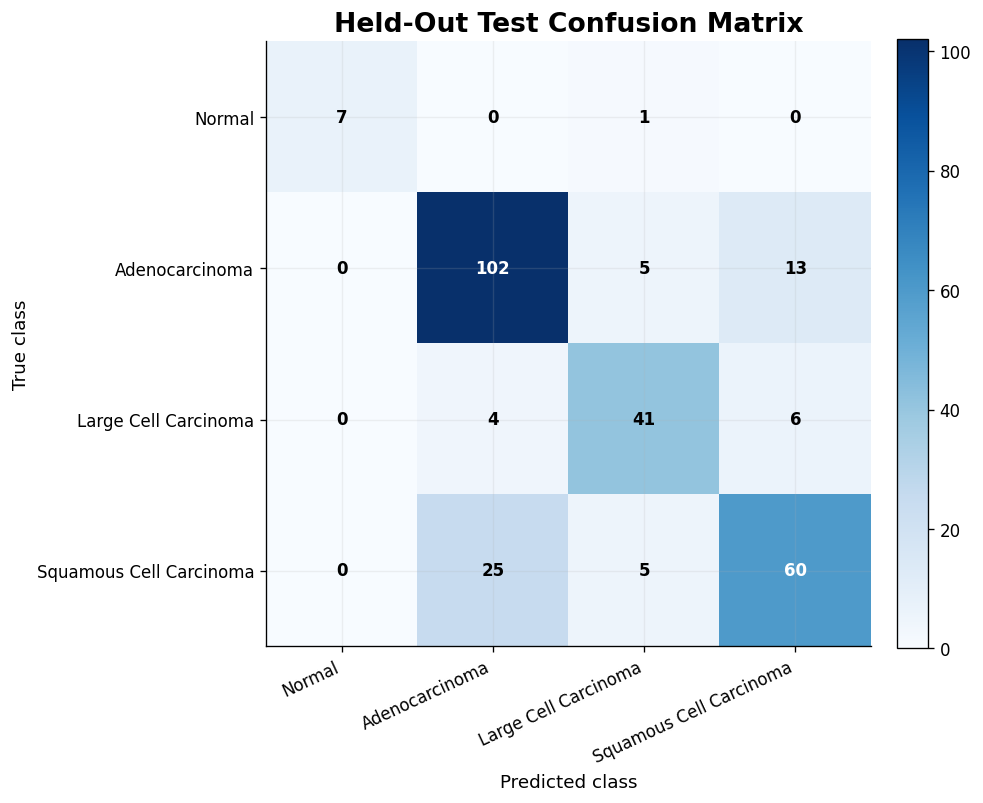

Saved: /kaggle/working/chest_ct_explainable_project/figures/test_cm_normalized.png


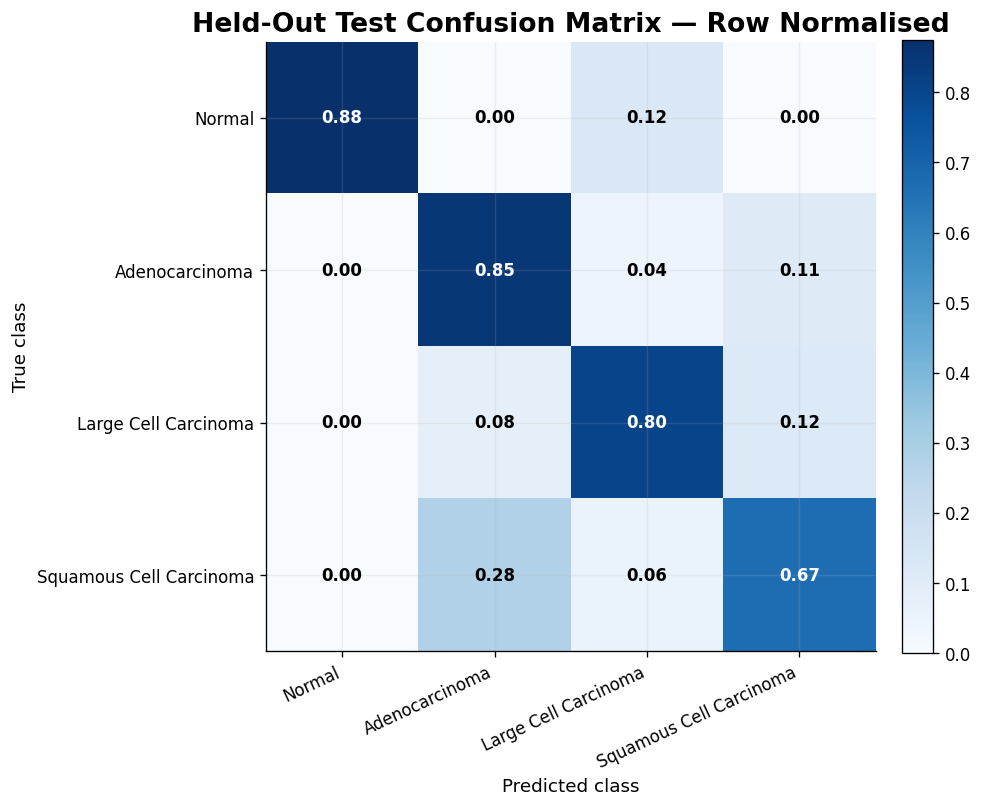

Saved: /kaggle/working/chest_ct_explainable_project/figures/test_per_class_metrics.png


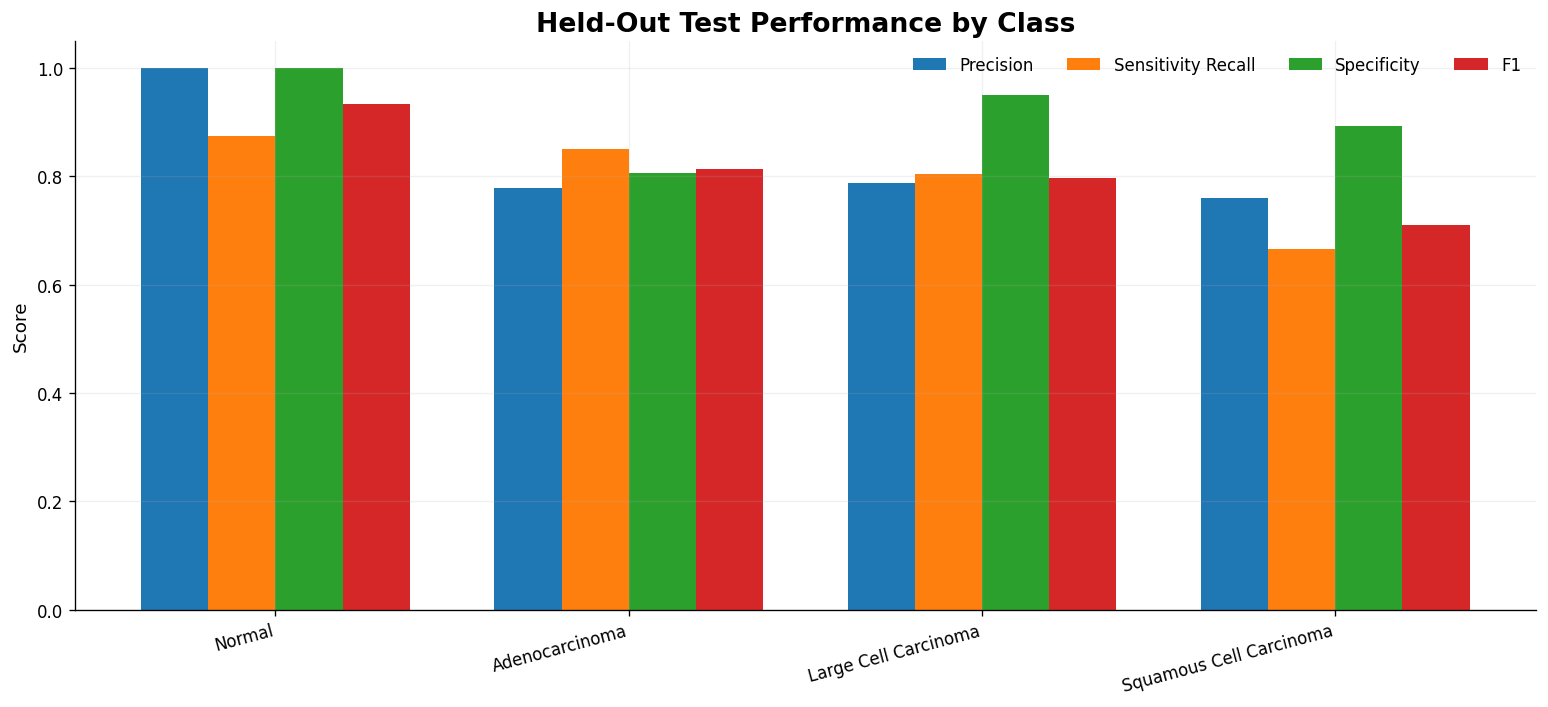

In [28]:
# 18. Confusion matrices and per-class metric profile
def draw_cm(m,title,norm=False):
    fig,ax=plt.subplots(figsize=(8,7)); im=ax.imshow(m,cmap='Blues'); fig.colorbar(im,ax=ax,fraction=.046,pad=.04)
    ax.set(xticks=np.arange(NUM_CLASSES),yticks=np.arange(NUM_CLASSES),xticklabels=[c.replace('_',' ').title() for c in CLASS_NAMES],
           yticklabels=[c.replace('_',' ').title() for c in CLASS_NAMES],xlabel='Predicted class',ylabel='True class',title=title)
    plt.setp(ax.get_xticklabels(),rotation=25,ha='right'); th=np.nanmax(m)/2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES): ax.text(j,i,f'{m[i,j]:.2f}' if norm else str(int(m[i,j])),ha='center',va='center',color='white' if m[i,j]>th else 'black',fontweight='bold')
    plt.tight_layout()
draw_cm(cm,'Held-Out Test Confusion Matrix'); save_figure('test_cm_raw'); plt.show()
cmn=cm/np.clip(cm.sum(1,keepdims=True),1,None); draw_cm(cmn,'Held-Out Test Confusion Matrix — Row Normalised',True); save_figure('test_cm_normalized'); plt.show()

metric_cols=['precision','sensitivity_recall','specificity','f1']; x=np.arange(NUM_CLASSES); width=.19
fig,ax=plt.subplots(figsize=(13,6))
for j,col in enumerate(metric_cols): ax.bar(x+(j-1.5)*width,per_class[col],width,label=col.replace('_',' ').title())
ax.set_xticks(x); ax.set_xticklabels([c.replace('_',' ').title() for c in CLASS_NAMES],rotation=15,ha='right'); ax.set_ylim(0,1.05)
ax.set(title='Held-Out Test Performance by Class',ylabel='Score'); ax.legend(frameon=False,ncol=4)
plt.tight_layout(); save_figure('test_per_class_metrics'); plt.show()

Saved: /kaggle/working/chest_ct_explainable_project/figures/test_roc_curves.png


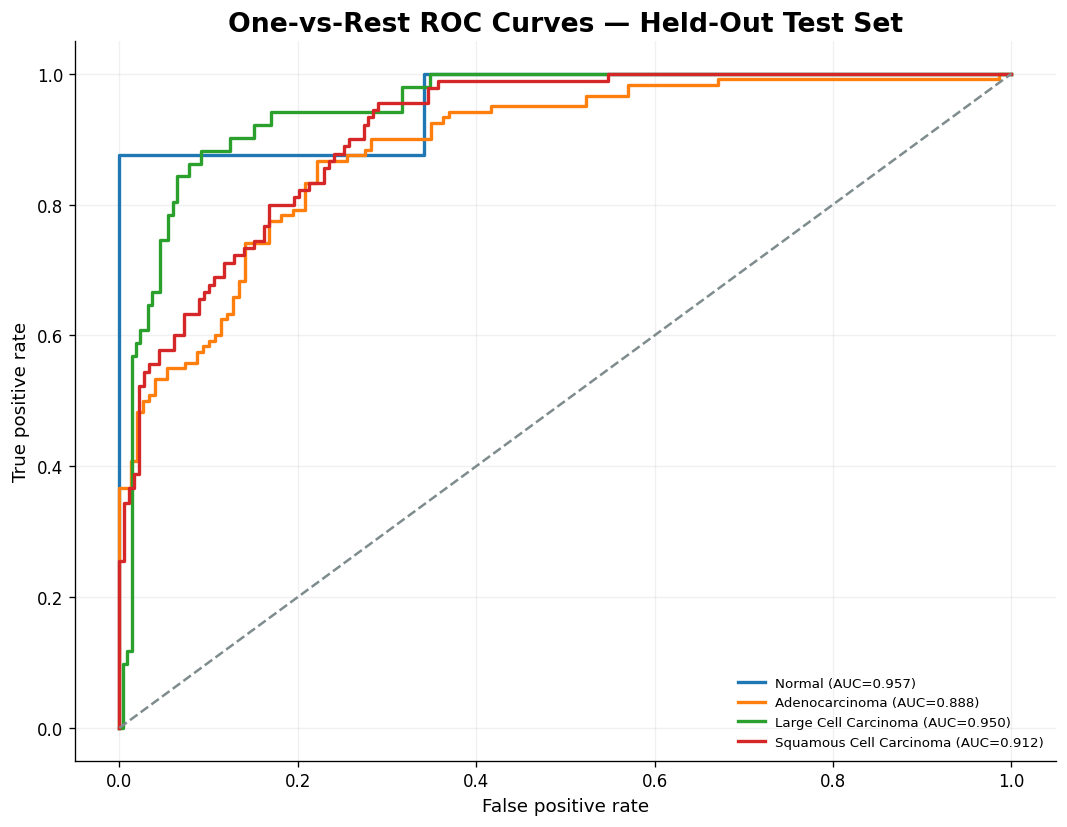

Saved: /kaggle/working/chest_ct_explainable_project/figures/test_pr_curves.png


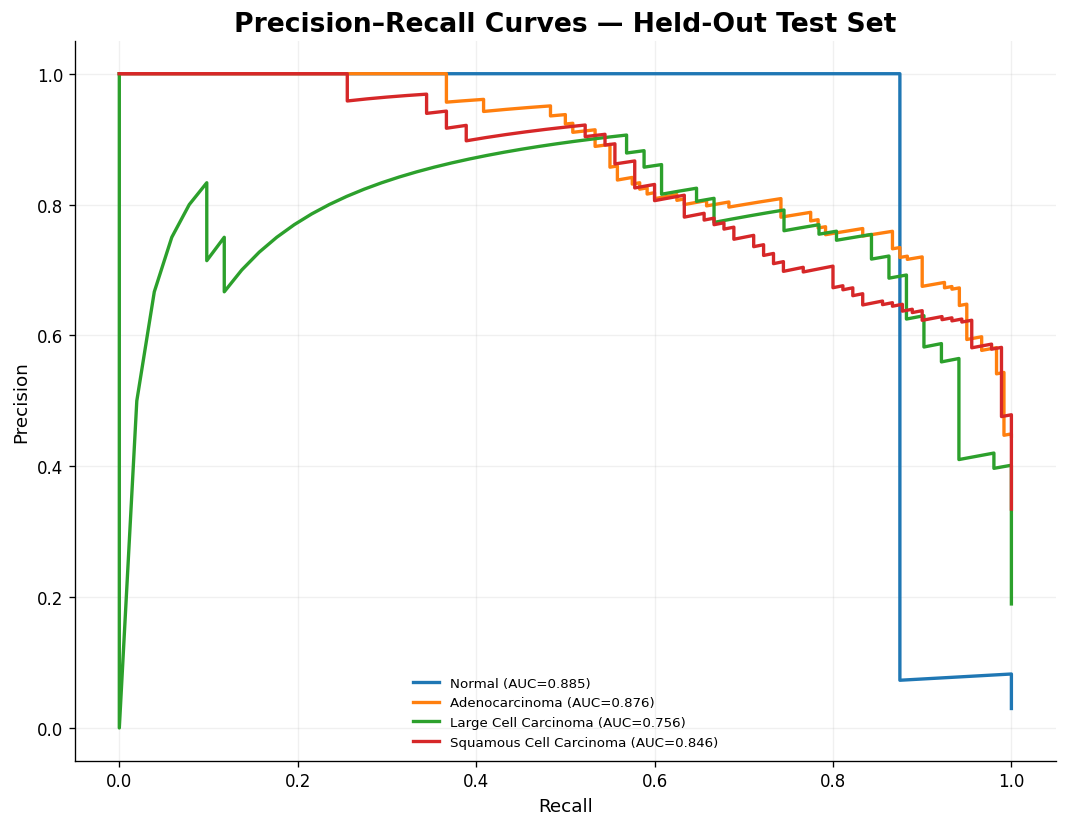

Saved: /kaggle/working/chest_ct_explainable_project/figures/test_confidence.png


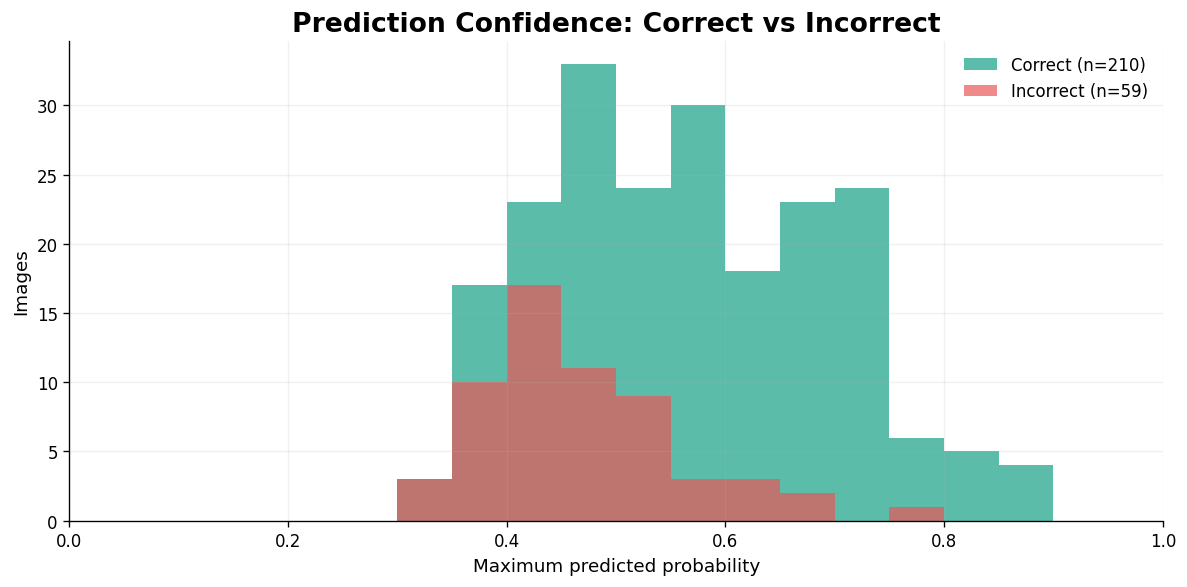

In [29]:
# 19. ROC, precision-recall and confidence analysis
onehot=label_binarize(TEST_Y,classes=np.arange(NUM_CLASSES))
fig,ax=plt.subplots(figsize=(9,7))
for i,c in enumerate(CLASS_NAMES):
    fpr,tpr,_=roc_curve(onehot[:,i],TEST_PROBS[:,i]); a=auc(fpr,tpr); ax.plot(fpr,tpr,linewidth=2,label=f"{c.replace('_',' ').title()} (AUC={a:.3f})")
ax.plot([0,1],[0,1],'--',color=PALETTE['grey']); ax.set(title='One-vs-Rest ROC Curves — Held-Out Test Set',xlabel='False positive rate',ylabel='True positive rate'); ax.legend(frameon=False,fontsize=8)
plt.tight_layout(); save_figure('test_roc_curves'); plt.show()

fig,ax=plt.subplots(figsize=(9,7))
for i,c in enumerate(CLASS_NAMES):
    p,r,_=precision_recall_curve(onehot[:,i],TEST_PROBS[:,i]); a=auc(r,p); ax.plot(r,p,linewidth=2,label=f"{c.replace('_',' ').title()} (AUC={a:.3f})")
ax.set(title='Precision–Recall Curves — Held-Out Test Set',xlabel='Recall',ylabel='Precision'); ax.legend(frameon=False,fontsize=8)
plt.tight_layout(); save_figure('test_pr_curves'); plt.show()

fig,ax=plt.subplots(figsize=(10,5)); cc=prediction_df.loc[prediction_df.correct,'confidence']; wc=prediction_df.loc[~prediction_df.correct,'confidence']
ax.hist(cc,bins=np.linspace(0,1,21),alpha=.70,label=f'Correct (n={len(cc)})',color=PALETTE['teal'])
if len(wc): ax.hist(wc,bins=np.linspace(0,1,21),alpha=.70,label=f'Incorrect (n={len(wc)})',color=PALETTE['red'])
ax.set(xlim=(0,1),title='Prediction Confidence: Correct vs Incorrect',xlabel='Maximum predicted probability',ylabel='Images'); ax.legend(frameon=False)
plt.tight_layout(); save_figure('test_confidence'); plt.show()
prediction_df['entropy']=-(TEST_PROBS*np.log(np.clip(TEST_PROBS,1e-8,1))).sum(1); prediction_df.to_csv(REPORT_DIR/'final_test_predictions.csv',index=False)

## 8. Error analysis and Grad-CAM
The most confident misclassifications are shown first. Grad-CAM is then used to inspect influential regions. Heatmaps are interpretability aids, not lesion annotations or proof of clinical correctness.

Saved: /kaggle/working/chest_ct_explainable_project/figures/test_error_gallery.png


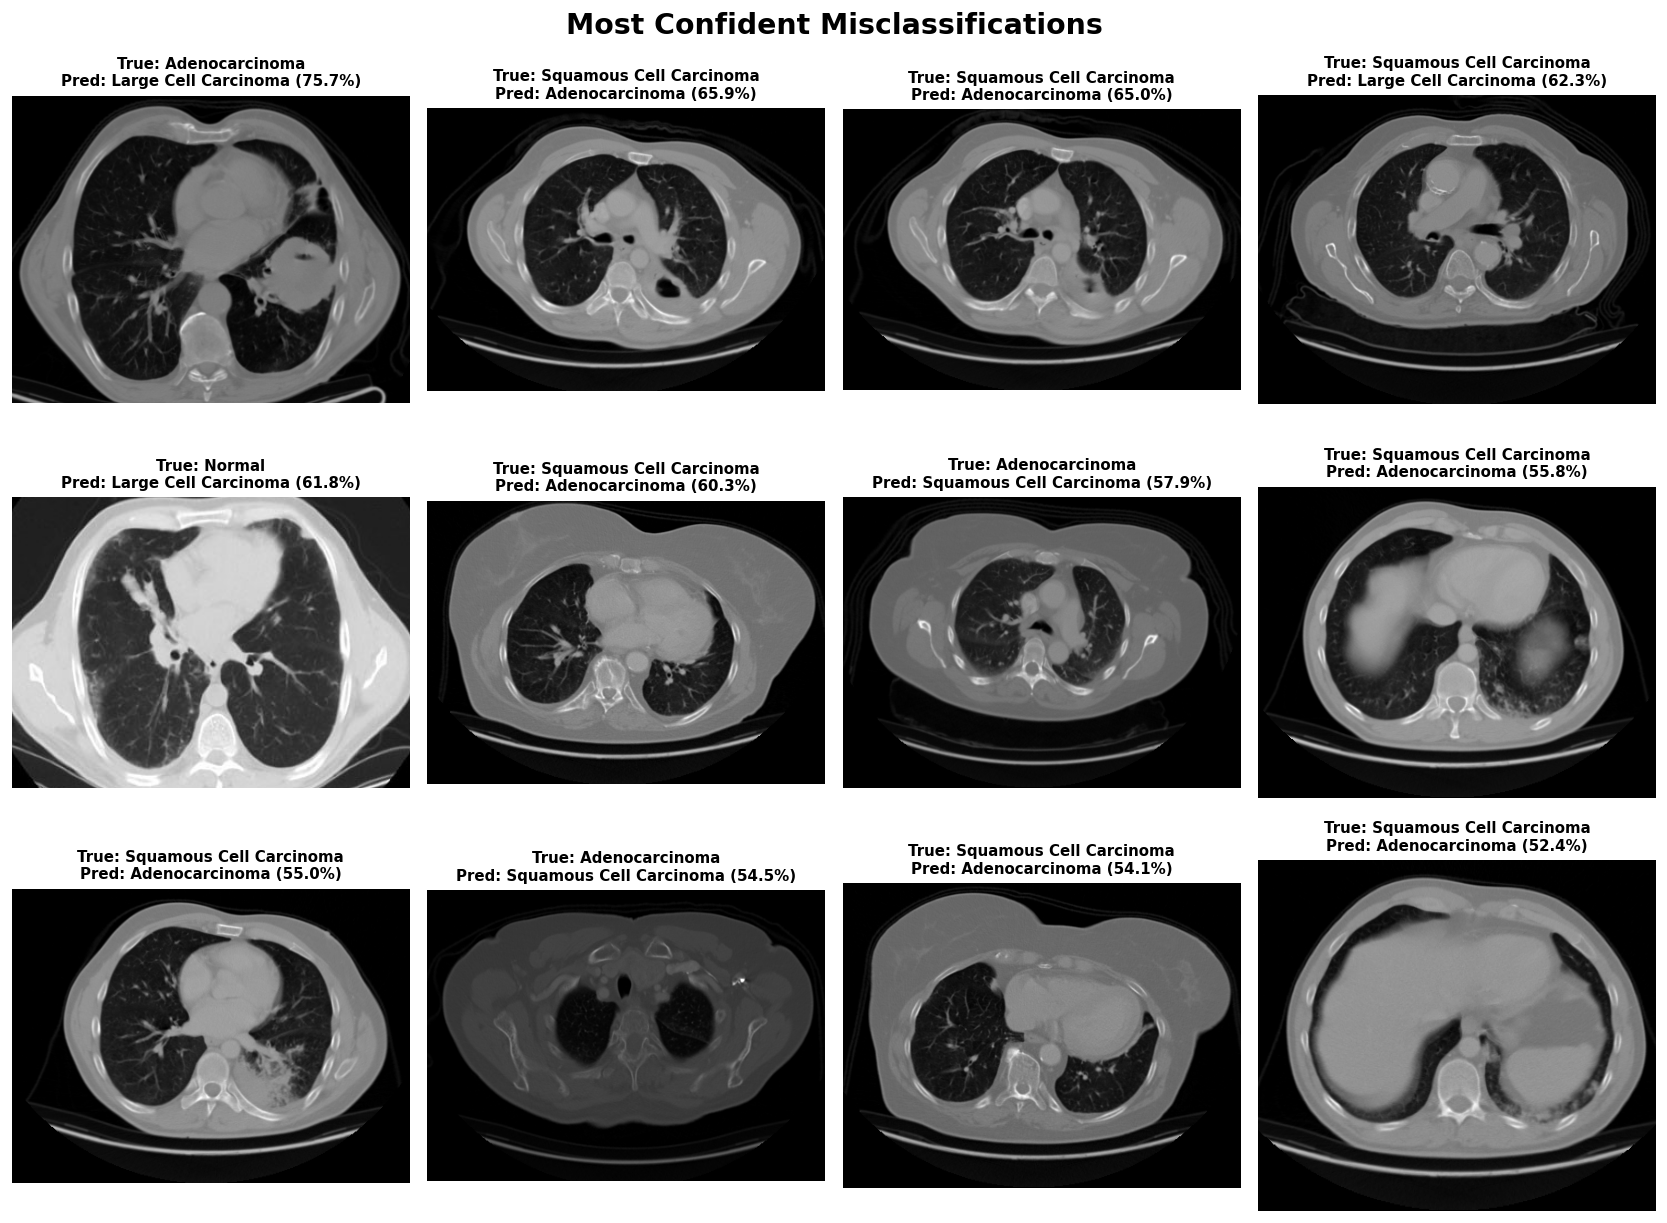

In [30]:
# 20. Error gallery
errors=prediction_df[~prediction_df.correct].sort_values('confidence',ascending=False)
gallery=errors.head(12) if len(errors) else prediction_df.sort_values('confidence').head(12)
title='Most Confident Misclassifications' if len(errors) else 'Lowest-Confidence Correct Predictions'
cols=4; rows=max(1,math.ceil(len(gallery)/cols)); fig,axes=plt.subplots(rows,cols,figsize=(14,rows*3.5)); axes=np.array(axes).reshape(-1)
for ax in axes: ax.axis('off')
for ax,(_,r) in zip(axes,gallery.iterrows()):
    with Image.open(r.path) as im: ax.imshow(im.convert('RGB'))
    ax.set_title(f"True: {r.label.replace('_',' ').title()}\nPred: {r.predicted_label.replace('_',' ').title()} ({r.confidence:.1%})",fontsize=9); ax.axis('off')
fig.suptitle(title,fontsize=17,fontweight='bold'); plt.tight_layout(); save_figure('test_error_gallery'); plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['ct_image']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Saved: /kaggle/working/chest_ct_explainable_project/figures/gradcam_gallery.png


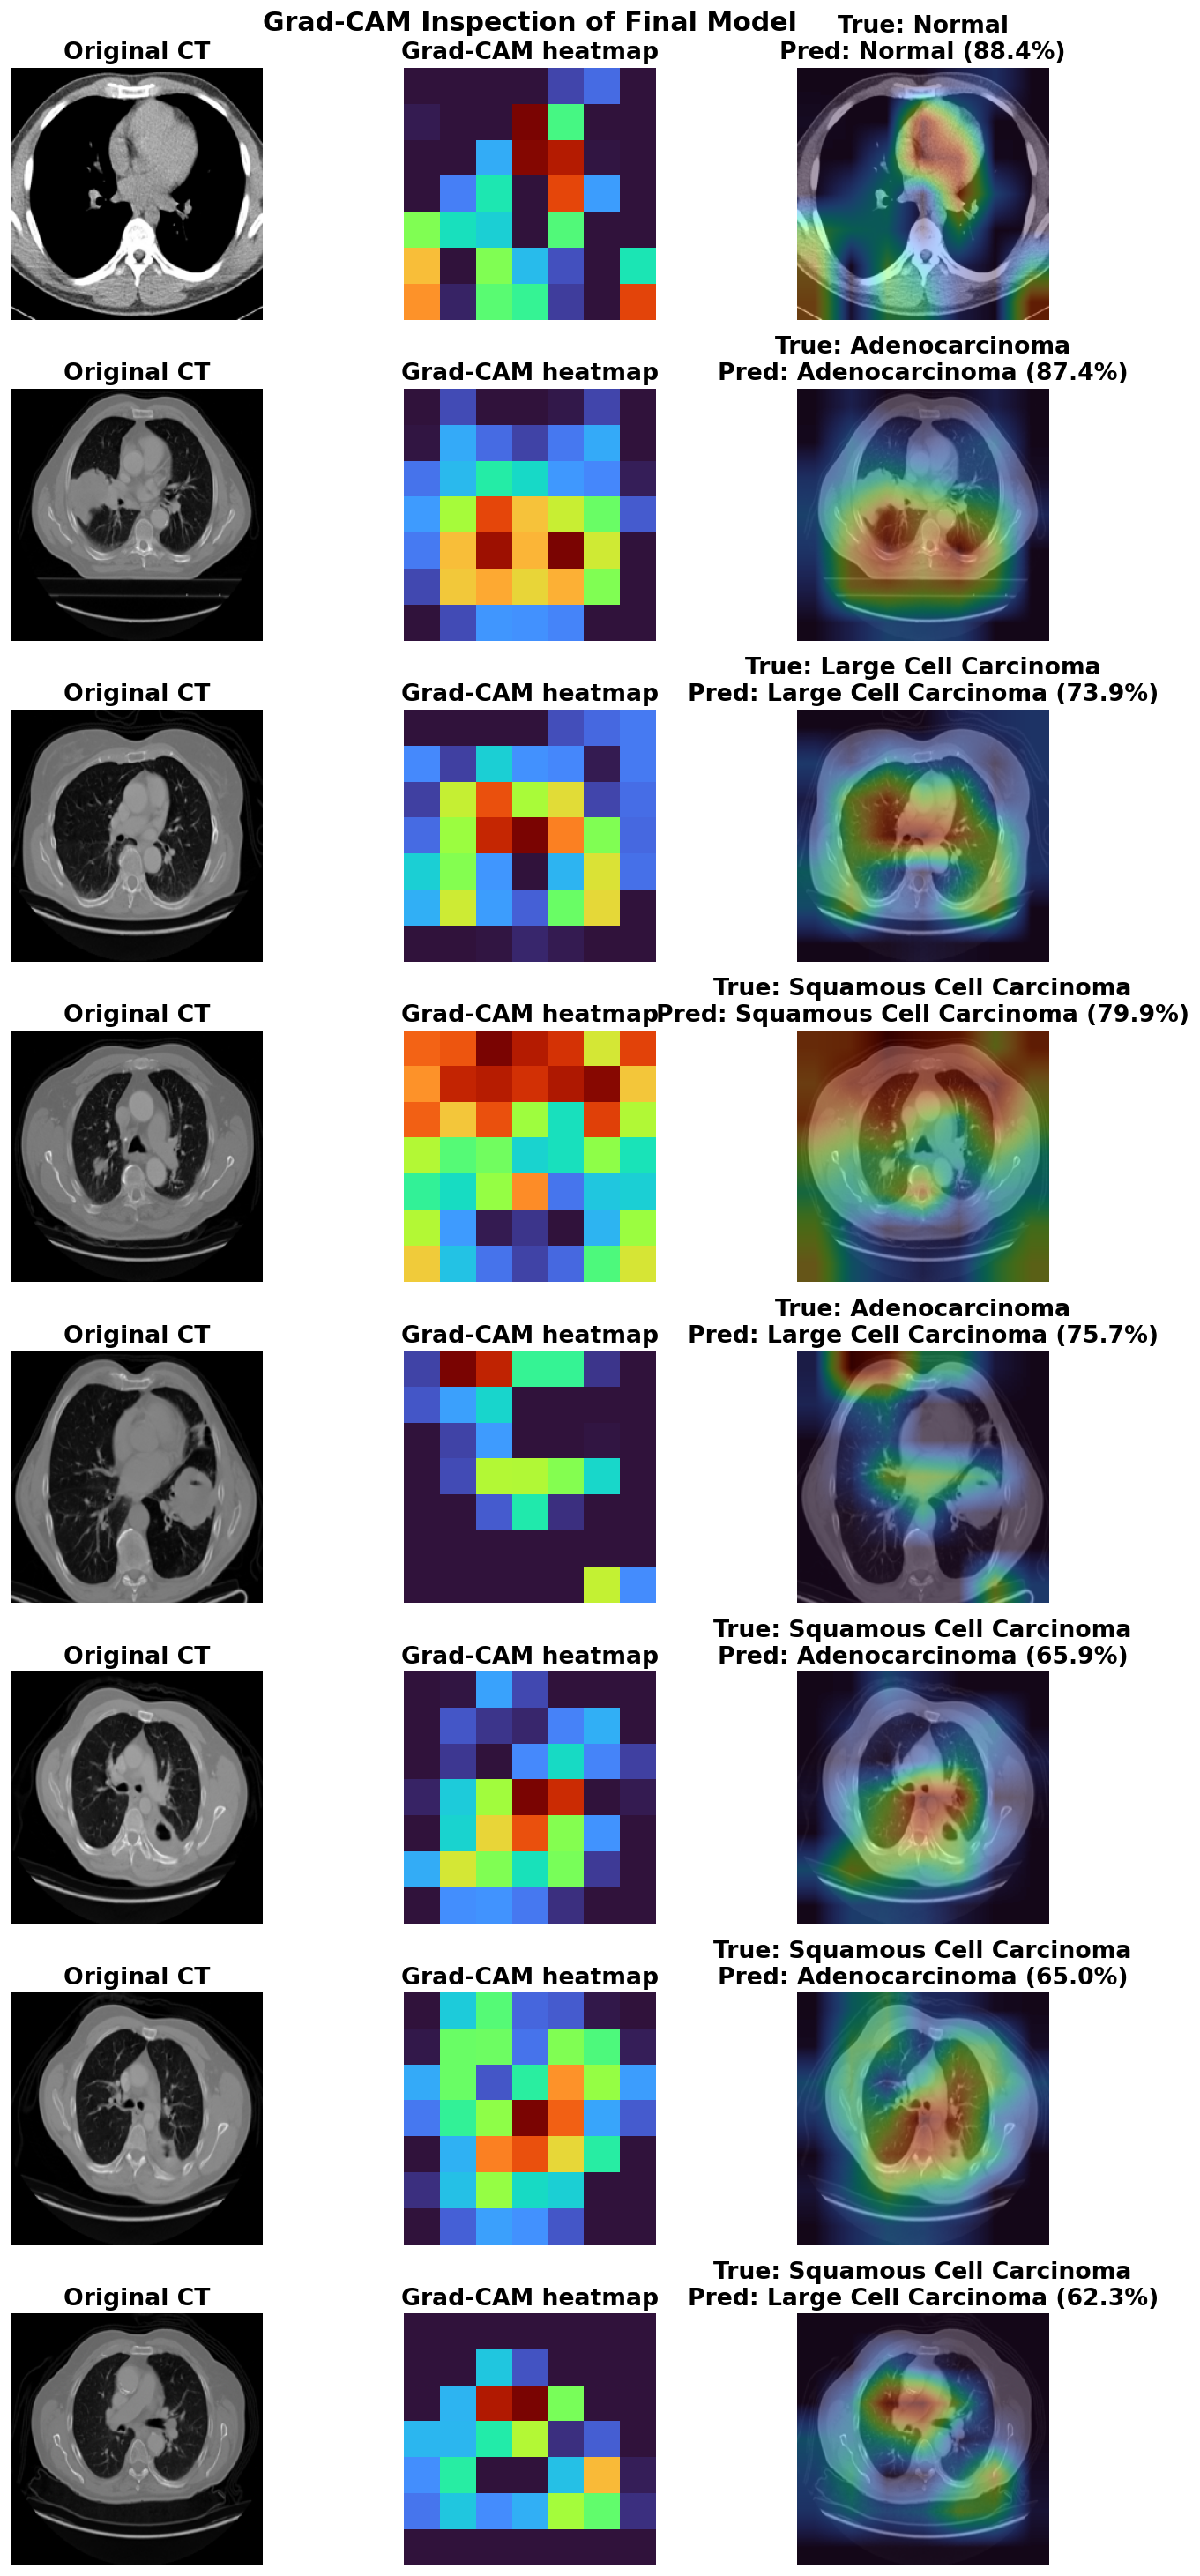

In [31]:
# 21. Grad-CAM utilities and gallery
def gradcam(model,batch,class_index=None):
    target=model.get_layer('gradcam_target'); probe=keras.Model(model.inputs,[target.output,model.output])
    with tf.GradientTape() as tape:
        fmap,pred=probe(batch,training=False); idx=tf.argmax(pred[0]) if class_index is None else class_index; score=pred[:,idx]
    grads=tape.gradient(score,fmap); w=tf.reduce_mean(grads,axis=(0,1,2)); heat=tf.reduce_sum(fmap[0]*w,axis=-1); heat=tf.maximum(heat,0)
    mx=tf.reduce_max(heat); heat=tf.where(mx>0,heat/mx,heat); return heat.numpy()
def load_rgb(path):
    with Image.open(path) as im: return np.asarray(im.convert('RGB').resize(IMG_SIZE),dtype=np.float32)
def overlay(image,heat,alpha=.42):
    h=Image.fromarray(np.uint8(np.clip(heat,0,1)*255)).resize(IMG_SIZE,Image.Resampling.BILINEAR); h=np.asarray(h,dtype=np.float32)/255
    colored=plt.get_cmap('turbo')(h)[...,:3]*255; return np.clip((1-alpha)*image+alpha*colored,0,255).astype(np.uint8)

selected=[]
for c in CLASS_NAMES:
    s=prediction_df[(prediction_df.label==c)&prediction_df.correct]
    if len(s): selected.append(s.sort_values('confidence',ascending=False).iloc[0])
if len(errors): selected.extend([r for _,r in errors.head(4).iterrows()])
selected=selected[:8]
fig,axes=plt.subplots(len(selected),3,figsize=(12,max(4,len(selected)*3.1))); axes=np.array(axes).reshape(len(selected),3)
for i,r in enumerate(selected):
    image=load_rgb(r.path); heat=gradcam(selected_model,np.expand_dims(image,0),int(r.predicted_idx)); ov=overlay(image,heat)
    axes[i,0].imshow(image.astype(np.uint8)); axes[i,0].set_title('Original CT')
    axes[i,1].imshow(heat,cmap='turbo'); axes[i,1].set_title('Grad-CAM heatmap')
    axes[i,2].imshow(ov); axes[i,2].set_title(f"True: {r.label.replace('_',' ').title()}\nPred: {r.predicted_label.replace('_',' ').title()} ({r.confidence:.1%})")
    for j in range(3): axes[i,j].axis('off')
fig.suptitle('Grad-CAM Inspection of Final Model',fontsize=18,fontweight='bold'); plt.tight_layout(); save_figure('gradcam_gallery'); plt.show()

## 9. Export the selected model and generate a local Flask application
The Flask prototype accepts JPG/JPEG/PNG, reports all class probabilities and displays a Grad-CAM overlay. It includes a prominent non-clinical disclaimer and deliberately avoids treatment advice.

In [32]:
# 22. Save final model metadata and profile
selected_path=PROJECT_DIR/'selected_model.keras'; shutil.copy2(SELECTED_MODEL_PATH,selected_path)
example,_=next(iter(test_ds)); _=selected_model.predict(example[:1],verbose=0); times=[]
for _ in range(20):
    t=time.perf_counter(); _=selected_model.predict(example[:1],verbose=0); times.append((time.perf_counter()-t)*1000)
metadata={'selected_model':SELECTED_MODEL_NAME,'selection_metric':'validation_macro_f1','class_names':CLASS_NAMES,'image_size':list(IMG_SIZE),
          'dataset':'Chest CT-Scan Images by Mohamed Hany (Kaggle)','dataset_url':'https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images',
          'licence':'Open Data Commons Open Database License (ODbL) v1.0','licence_url':'https://opendatacommons.org/licenses/odbl/1-0/',
          'academic_use_notice':'Academic classification prototype only; not for clinical diagnosis or treatment.',
          'tensorflow_version':tf.__version__,'parameters':int(selected_model.count_params()),'model_size_mb':os.path.getsize(selected_path)/(1024**2),
          'median_inference_ms':float(np.median(times)),'final_test_metrics':{k:float(v) for k,v in test_summary.items()}}
with open(PROJECT_DIR/'class_names.json','w') as f: json.dump(CLASS_NAMES,f,indent=2)
with open(PROJECT_DIR/'model_metadata.json','w') as f: json.dump(metadata,f,indent=2)
display(pd.DataFrame([metadata])[['selected_model','parameters','model_size_mb','median_inference_ms']])

2026-08-12 18:10:20.112766: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,selected_model,parameters,model_size_mb,median_inference_ms
0,efficientnetb0,4411943,35.125738,101.940547


In [33]:
# 23. Build Flask deployment bundle
ART=FLASK_DIR/'artifacts'; TPL=FLASK_DIR/'templates'; STATIC=FLASK_DIR/'static'; GEN=STATIC/'generated'
for d in [ART,TPL,STATIC,GEN]: d.mkdir(parents=True,exist_ok=True)
shutil.copy2(PROJECT_DIR/'selected_model.keras',ART/'selected_model.keras'); shutil.copy2(PROJECT_DIR/'class_names.json',ART/'class_names.json'); shutil.copy2(PROJECT_DIR/'model_metadata.json',ART/'model_metadata.json')

app_py=r'''import json, uuid
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
import matplotlib.pyplot as plt
from flask import Flask, render_template, request
from werkzeug.utils import secure_filename
BASE=Path(__file__).resolve().parent; ART=BASE/'artifacts'; OUT=BASE/'static'/'generated'; OUT.mkdir(parents=True,exist_ok=True)
ALLOWED={'jpg','jpeg','png'}
@keras.utils.register_keras_serializable(package='ChestCT')
class DenseNetInputTransform(layers.Layer):
    def call(self,inputs): return keras.applications.densenet.preprocess_input(inputs)
    def get_config(self): return super().get_config()
CLASS_NAMES=json.load(open(ART/'class_names.json')); META=json.load(open(ART/'model_metadata.json')); IMG_SIZE=tuple(META.get('image_size',[224,224]))
MODEL=keras.models.load_model(ART/'selected_model.keras',custom_objects={'DenseNetInputTransform':DenseNetInputTransform})
app=Flask(__name__); app.config['MAX_CONTENT_LENGTH']=10*1024*1024
def allowed(name): return '.' in name and name.rsplit('.',1)[1].lower() in ALLOWED
def prep(path):
    with Image.open(path) as im: return np.asarray(im.convert('RGB').resize(IMG_SIZE),dtype=np.float32)
def heatmap(batch,idx):
    target=MODEL.get_layer('gradcam_target'); probe=keras.Model(MODEL.inputs,[target.output,MODEL.output])
    with tf.GradientTape() as tape: fmap,p=probe(batch,training=False); score=p[:,idx]
    grads=tape.gradient(score,fmap); w=tf.reduce_mean(grads,axis=(0,1,2)); h=tf.reduce_sum(fmap[0]*w,axis=-1); h=tf.maximum(h,0); m=tf.reduce_max(h); return tf.where(m>0,h/m,h).numpy()
def save_overlay(image,h,path):
    hi=Image.fromarray(np.uint8(np.clip(h,0,1)*255)).resize(IMG_SIZE,Image.Resampling.BILINEAR); a=np.asarray(hi,dtype=np.float32)/255
    color=plt.get_cmap('turbo')(a)[...,:3]*255; Image.fromarray(np.clip(.58*image+.42*color,0,255).astype(np.uint8)).save(path)
@app.route('/',methods=['GET','POST'])
def index():
    result=None; error=None
    if request.method=='POST':
        f=request.files.get('ct_image')
        if not f or not f.filename: error='Please choose a CT image.'
        elif not allowed(f.filename): error='Only JPG, JPEG and PNG files are accepted.'
        else:
            token=uuid.uuid4().hex[:12]; name=token+'_'+secure_filename(f.filename); path=OUT/name; f.save(path)
            try:
                image=prep(path); probs=MODEL.predict(np.expand_dims(image,0),verbose=0)[0]; idx=int(np.argmax(probs)); hm=heatmap(np.expand_dims(image,0),idx)
                grad_name=token+'_gradcam.png'; save_overlay(image,hm,OUT/grad_name)
                ranked=sorted([{'label':CLASS_NAMES[i].replace('_',' ').title(),'probability':float(probs[i])} for i in range(len(CLASS_NAMES))],key=lambda x:x['probability'],reverse=True)
                result={'predicted_class':CLASS_NAMES[idx].replace('_',' ').title(),'confidence':float(probs[idx]),'probabilities':ranked,'input_image':'generated/'+name,'gradcam_image':'generated/'+grad_name,'model_name':META.get('selected_model','Model')}
            except Exception as exc: error='Prediction failed: '+str(exc)
    return render_template('index.html',result=result,error=error,metadata=META)
if __name__=='__main__': app.run(host='127.0.0.1',port=5000,debug=False)
'''

html=r'''<!doctype html><html lang="en"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1"><title>Chest CT Explainable AI</title><link rel="stylesheet" href="{{ url_for('static', filename='style.css') }}"></head><body><main class="shell"><section class="hero"><div><p class="eyebrow">ACADEMIC PROTOTYPE</p><h1>Explainable Chest CT Classification</h1><p>Upload one JPG/PNG CT image for a four-class prediction and Grad-CAM explanation.</p></div><div class="badge">{{ metadata.get('selected_model','Model') }}</div></section><section class="warning"><strong>Not for clinical use.</strong> This research prototype does not diagnose cancer or provide treatment advice.</section><section class="card"><form method="post" enctype="multipart/form-data"><input name="ct_image" type="file" accept=".jpg,.jpeg,.png" required><button>Analyse image</button></form>{% if error %}<p class="error">{{ error }}</p>{% endif %}</section>{% if result %}<section class="grid"><article class="card"><p class="eyebrow">MODEL OUTPUT</p><h2>{{ result.predicted_class }}</h2><div class="confidence">{{ "%.1f"|format(result.confidence*100) }}%</div>{% for item in result.probabilities %}<div class="row"><span>{{ item.label }}</span><div class="bar"><i style="width:{{ '%.1f'|format(item.probability*100) }}%"></i></div><b>{{ "%.1f"|format(item.probability*100) }}%</b></div>{% endfor %}</article><article class="card"><p class="eyebrow">UPLOADED IMAGE</p><img src="{{ url_for('static',filename=result.input_image) }}"></article><article class="card"><p class="eyebrow">GRAD-CAM</p><img src="{{ url_for('static',filename=result.gradcam_image) }}"><small>Highlighted regions influenced the model; they are not validated lesion annotations.</small></article></section>{% endif %}<footer>Chest CT-Scan Images by Mohamed Hany • ODbL v1.0 • Secondary data only</footer></main></body></html>'''

css='''body{margin:0;font-family:Segoe UI,Arial,sans-serif;background:#f2f7fb;color:#17324d}.shell{max-width:1180px;margin:auto;padding:36px 20px}.hero{display:flex;justify-content:space-between;gap:25px;background:linear-gradient(135deg,#0f2438,#176080);color:white;padding:32px;border-radius:24px}.hero h1{font-size:44px;margin:5px 0}.badge{background:#ffffff20;padding:12px 16px;border-radius:999px;height:max-content}.warning{margin:18px 0;background:#fff4e5;border:1px solid #f5c26b;padding:15px;border-radius:14px}.card{background:white;border-radius:18px;padding:22px;box-shadow:0 10px 30px #17324d18;margin-top:16px}.grid{display:grid;grid-template-columns:1.05fr 1fr 1fr;gap:16px}.card img{width:100%;aspect-ratio:1;object-fit:contain;background:#08141e;border-radius:12px}.confidence{font-size:60px;color:#16a085;font-weight:900}.row{display:grid;grid-template-columns:145px 1fr 55px;gap:9px;align-items:center;margin:12px 0;font-size:13px}.bar{height:9px;background:#e6edf3;border-radius:99px;overflow:hidden}.bar i{display:block;height:100%;background:linear-gradient(90deg,#2f80ed,#16a085)}button{background:#2f80ed;color:white;border:0;border-radius:10px;padding:12px 20px;font-weight:700}.eyebrow{font-size:12px;letter-spacing:.13em;font-weight:800}.error{color:#b42318}.grid+footer,footer{text-align:center;color:#60758a;padding:28px}@media(max-width:900px){.grid{grid-template-columns:1fr}.hero{flex-direction:column}}'''

readme='''# Local Flask prototype\n\nAcademic prototype only; not for clinical diagnosis or treatment.\n\n## Windows PowerShell\npython -m venv .venv\n.venv\\Scripts\\Activate.ps1\npython -m pip install --upgrade pip\npip install -r requirements.txt\npython app.py\n\n## macOS/Linux\npython3 -m venv .venv\nsource .venv/bin/activate\npip install -r requirements.txt\npython app.py\n\nOpen http://127.0.0.1:5000\n'''
requirements=f'Flask>=3.0,<4\ntensorflow=={tf.__version__}\nnumpy>=1.24\nPillow>=10\nmatplotlib>=3.7\n'
(FLASK_DIR/'app.py').write_text(app_py,encoding='utf-8'); (TPL/'index.html').write_text(html,encoding='utf-8'); (STATIC/'style.css').write_text(css,encoding='utf-8')
(FLASK_DIR/'README.md').write_text(readme,encoding='utf-8'); (FLASK_DIR/'requirements.txt').write_text(requirements,encoding='utf-8')
print('Flask app prepared at',FLASK_DIR)

Flask app prepared at /kaggle/working/chest_ct_explainable_project/flask_app


In [34]:
# 24. Zip deployment and research outputs
flask_zip=shutil.make_archive(str(PROJECT_DIR/'Chest_CT_Flask_App'),'zip',root_dir=FLASK_DIR)
print('Flask bundle:',flask_zip)
print('\nResearch output inventory:')
for p in sorted(PROJECT_DIR.rglob('*')):
    if p.is_file(): print(f'{p.relative_to(PROJECT_DIR)} | {p.stat().st_size/(1024**2):.2f} MB')

Flask bundle: /kaggle/working/chest_ct_explainable_project/Chest_CT_Flask_App.zip

Research output inventory:
Chest_CT_Flask_App.zip | 31.88 MB
class_names.json | 0.00 MB
figures/eda_01_split_sizes.png | 0.05 MB
figures/eda_02_class_distribution.png | 0.09 MB
figures/eda_03_dimensions.png | 0.15 MB
figures/eda_04_file_sizes.png | 0.04 MB
figures/eda_05_brightness.png | 0.09 MB
figures/eda_06_gallery.png | 2.90 MB
figures/eda_07_leakage.png | 0.05 MB
figures/eda_08_augmentation.png | 0.99 MB
figures/gradcam_gallery.png | 2.64 MB
figures/model_comparison_validation.png | 0.06 MB
figures/model_parameter_comparison.png | 0.05 MB
figures/test_cm_normalized.png | 0.12 MB
figures/test_cm_raw.png | 0.10 MB
figures/test_confidence.png | 0.05 MB
figures/test_error_gallery.png | 1.81 MB
figures/test_per_class_metrics.png | 0.08 MB
figures/test_pr_curves.png | 0.10 MB
figures/test_roc_curves.png | 0.10 MB
figures/training_custom_cnn.png | 0.12 MB
figures/training_densenet121.png | 0.19 MB
figures/

## Reproducibility checklist
Expected outputs include the raw/audited/modelling manifests, exact/near-duplicate reports, validation model comparison, training histories, final test predictions and metrics, per-class metrics, saved EDA/testing/Grad-CAM figures, `selected_model.keras`, class metadata and `Chest_CT_Flask_App.zip`.

### Dissertation interpretation rules
- Use only metrics generated by this notebook run.
- Distinguish validation model selection from held-out test evaluation.
- Do not claim clinical validity from a small public image dataset.
- State that patient-level independence cannot be verified without patient identifiers.
- Treat Grad-CAM as an interpretability aid, not a medical localisation ground truth.

## References
- Mohamed Hany. **Chest CT-Scan Images**. Kaggle. https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images
- Open Data Commons. **Open Database License (ODbL) v1.0**. https://opendatacommons.org/licenses/odbl/1-0/
- Tan, M. & Le, Q.V. (2019). **EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks**. ICML, PMLR 97.
- Huang, G., Liu, Z., Van Der Maaten, L. & Weinberger, K.Q. (2017). **Densely Connected Convolutional Networks**. CVPR. DOI: 10.1109/CVPR.2017.243.
- Selvaraju, R.R. et al. (2017). **Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization**. ICCV. DOI: 10.1109/ICCV.2017.74.

In [35]:
import shutil
from IPython.display import FileLink, display

folder_path = "/kaggle/working/chest_ct_explainable_project"
zip_name = "/kaggle/working/chest_ct_explainable_project"

zip_path = shutil.make_archive(
    base_name=zip_name,
    format="zip",
    root_dir=folder_path
)

print(f"ZIP created: {zip_path}")
display(FileLink(zip_path))

ZIP created: /kaggle/working/chest_ct_explainable_project.zip


/kaggle/working/chest_ct_explainable_project.zip